<a href="https://colab.research.google.com/github/taposhkumer/Best_CPU_SCHEDULING_ALGORITHM_SELECT_USING_ML/blob/main/AI_Assisted_Hybrid_CPU_Scheduling_with_Burst_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Title: **"AI-Assisted Hybrid CPU Scheduling with Burst Prediction Using Machine Learning"**


This project proposes an AI-assisted hybrid CPU scheduling framework that predicts CPU burst time of incoming processes using machine learning techniques. Based on the predicted burst duration, a dynamic decision engine selects the most appropriate scheduling algorithm (Shortest Job First, Round Robin, or Priority Scheduling) to optimize system performance metrics such as average waiting time, turnaround time, and CPU utilization.

The system collects process execution features, trains a regression model to estimate burst time, and integrates the prediction into a simulated operating system scheduling environment.

###🔹 **Predict Burst Time (Machine Learning Module)**
**Objective**

To estimate the CPU burst time of incoming processes using a regression-based machine learning model.


**Step 1:** Dataset Preparation

Collect process/job execution data from system logs or workload traces.

Extract relevant features:

'SubmitTime', 'WaitTime', 'NProcs', 'AverageCPUTimeUsed', 'Used Memory',
       'ReqNProcs', 'ReqTime: ', 'ReqMemory', 'Status', 'PartitionID',
       'QueueNO', 'GroupNO', 'ExecutableNO', 'OrigSiteNO', 'LastRunSiteNO',
       'USERNO
The computed BurstTime is used as the target variable for model training.



**Step 2:** Model Training

Split dataset into training and testing sets.

Train a regression model (e.g.,linear regression).


**Step 3:** Burst Prediction

For a new incoming process:

Provide feature inputs:

SubmitTime', 'WaitTime', 'NProcs', 'AverageCPUTimeUsed', 'Used Memory',
       'ReqNProcs', 'ReqTime: ', 'ReqMemory', 'Status', 'PartitionID',
       'QueueNO', 'GroupNO', 'ExecutableNO', 'OrigSiteNO', 'LastRunSiteNO',
       'USERNO

The trained model predicts:

Predicted_Burst_Time

This predicted burst time is forwarded to the hybrid scheduling engine.




###🔹 **Hybrid Scheduling Engine**
**Objective**

To dynamically select the most appropriate scheduling algorithm based on predicted burst time.

Decision Logic


If:

predicted_burst < SHORT_LIMIT
→ Select Shortest Job First (SJF)

SHORT_LIMIT ≤ predicted_burst < MEDIUM_LIMIT
→ Select Priority Scheduling

predicted_burst ≥ MEDIUM_LIMIT
→ Select Round Robin



**Purpose of Hybrid Approach**

Small jobs → SJF reduces waiting time.

Medium jobs → Priority Scheduling ensures fairness.

Large jobs → Round Robin prevents starvation.

The selected algorithm is then passed to the scheduling simulator.



###🔹 **Scheduling Simulation**
**Objective**

To simulate CPU scheduling behavior and evaluate system performance.

**Simulation Components**


1️⃣ Ready Queue

Stores processes waiting for execution.

2️⃣ CPU Execution Model

Simulates execution according to the selected scheduling algorithm.

3️⃣ Performance Metrics Calculation

For each process:

Waiting Time

Turnaround Time

Completion Time

System-level metrics:

Average Waiting Time

Average Turnaround Time

CPU Utilization




**Performance Comparison**

The system compares:

Traditional Scheduling Algorithms
(SJF, Round Robin, Priority individually)

vs

AI-Based Hybrid Scheduling

Evaluation criteria:

Reduced average waiting time

Improved turnaround time

Better CPU utilization

Reduced starvation

## ============================
# 1. Install and Import Libraries ⚙️
## ============================

In [94]:
!pip install -q  missingno    # Install missingno for missing data visualization

In [95]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms

#1%matplotlib inline    # Inline plotting for Colab
from sklearn.metrics import confusion_matrix, classification_report,precision_score,f1_score,accuracy_score, r2_score   # Import ML metrics

## ============================
# 2. Load Dataset 📂
## ============================

In [96]:
!wget https://www.dropbox.com/s/ikyxo0zew514a0b/processes_datasets.csv # Downloads the dataset 'processes_datasets.csv' from a Dropbox URL.

--2026-06-13 15:10:15--  https://www.dropbox.com/s/ikyxo0zew514a0b/processes_datasets.csv
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/h7expu9n3e04pddcl494y/processes_datasets.csv?rlkey=3lcfn9mx2ndnswqa5gb8ct0kb [following]
--2026-06-13 15:10:16--  https://www.dropbox.com/scl/fi/h7expu9n3e04pddcl494y/processes_datasets.csv?rlkey=3lcfn9mx2ndnswqa5gb8ct0kb
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucc4d6123d58befcecca30a4d2e6.dl.dropboxusercontent.com/cd/0/inline/DCUCDWGA-HtrVM5Y7YxSPoG-j8oV23ZoJD7kxxhX1JE5mCzXrrYA21U05ZCVg6bi3dvqozU6-1rXgWutVdfFy0y9MEKT8CqY4a6O4sNcrCxMFvNaYJNl_B4TiKuetTPi6p0/file# [following]
--2026-06-13 15:10:16--  https://ucc4d6123d58befcecca30a4d2e6.dl.dropboxusercontent.com/cd/0

In [97]:
# Read CSV into pandas DataFrame

data = pd.read_csv('processes_datasets.csv')

In [98]:
data = data[:1000]

In [99]:
# Remove invalid runtime values (negative = missing/invalid in dataset)
data = data[data['RunTime '] >= 0].copy()

# Optional: reset index after filtering
data.reset_index(drop=True, inplace=True)

print("Remaining rows:", len(data))
print("Min runtime:", data['RunTime '].min())

Remaining rows: 957
Min runtime: 2


## ============================
# 3. Explore Data 🔍
## ============================

In [100]:
data.head()   # Display the first 5 rows

,JobID,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,...,JobStructureParams,UsedNetwork,UsedLocalDiskSpace,UsedResources,ReqPlatform,ReqNetwork,ReqLocalDiskSpace,ReqResources,VOID,ProjectID
0,1,1136070024,203761,138467,1,138371,98652,1,259200,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,2,1136070690,0,11,1,4,35848,1,259200,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,3,1136071207,117,201203,1,0,0,1,259200,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,4,1136071267,4406,196985,1,0,0,1,259200,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,5,1136071269,202516,19520,1,18731,522268,1,259200,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [101]:
data.tail()   # Show last 5 rows

,JobID,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,...,JobStructureParams,UsedNetwork,UsedLocalDiskSpace,UsedResources,ReqPlatform,ReqNetwork,ReqLocalDiskSpace,ReqResources,VOID,ProjectID
952,994,1136325144,389,505,1,232,950312,1,31980,614400,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
953,995,1136325144,424,619,1,342,877040,1,31980,614400,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
954,996,1136325145,423,470,1,202,934140,1,31980,614400,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
955,997,1136325172,118549,98174,1,96482,152700,1,259200,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
956,1000,1136325292,118256,94088,1,93229,152708,1,259200,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [102]:
type(data)    # Check the object type

pandas.core.frame.DataFrame

In [103]:
data.shape    # Get dataset dimensions (rows, columns)

(957, 29)

In [104]:
data.info()   # Quick summary: columns, non‑null counts, dtypes, memory

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   JobID               957 non-null    int64 
 1   SubmitTime          957 non-null    int64 
 2   WaitTime            957 non-null    int64 
 3   RunTime             957 non-null    int64 
 4   NProcs              957 non-null    int64 
 5   AverageCPUTimeUsed  957 non-null    int64 
 6   Used Memory         957 non-null    int64 
 7   ReqNProcs           957 non-null    int64 
 8   ReqTime:            957 non-null    int64 
 9   ReqMemory           957 non-null    int64 
 10  Status              957 non-null    int64 
 11  UserID              957 non-null    object
 12  GroupID             957 non-null    object
 13  ExecutableID        957 non-null    object
 14  QueueID             957 non-null    object
 15  PartitionID         957 non-null    int64 
 16  OrigSiteID          957 no

In [105]:
data.sum()    # Sum of each numeric column

,0
JobID,487639
SubmitTime,1087429739084
WaitTime,26290669
RunTime,15789218
NProcs,957
AverageCPUTimeUsed,13227509
Used Memory,164208796
ReqNProcs,957
ReqTime:,86297220
ReqMemory,297369127


In [106]:
data.describe()   # Statistical summary (count, mean, std, min, quartiles, max)

,JobID,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,...,JobStructureParams,UsedNetwork,UsedLocalDiskSpace,UsedResources,ReqPlatform,ReqNetwork,ReqLocalDiskSpace,ReqResources,VOID,ProjectID
count,957.000000,9.570000e+02,9.570000e+02,957.000000,957.0,957.000000,957.000000,957.0,957.000000,957.000000,...,957.0,957.0,957.0,957.0,957.0,957.0,957.0,957.0,957.0,957.0
mean,509.549634,1.136290e+09,2.747196e+04,16498.660397,1.0,13821.848485,171587.038662,1.0,90174.733542,310730.540230,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
std,288.347309,3.188653e+04,2.541860e+05,38170.768599,0.0,33469.565043,297369.696069,0.0,100098.401401,307340.823107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.000000,1.136070e+09,0.000000e+00,2.000000,1.0,0.000000,0.000000,1.0,900.000000,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
25%,252.000000,1.136284e+09,1.000000e+00,31.000000,1.0,3.000000,35720.000000,1.0,31980.000000,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
50%,520.000000,1.136291e+09,1.000000e+00,1850.000000,1.0,8.000000,57528.000000,1.0,31980.000000,614400.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
75%,759.000000,1.136299e+09,2.000000e+00,1852.000000,1.0,200.000000,152664.000000,1.0,172800.000000,614400.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
max,1000.000000,1.136325e+09,2.629516e+06,259302.000000,1.0,138371.000000,984764.000000,1.0,259200.000000,614400.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


## ============================
# 4. Analyse Data 🧩
## ============================



<Axes: >

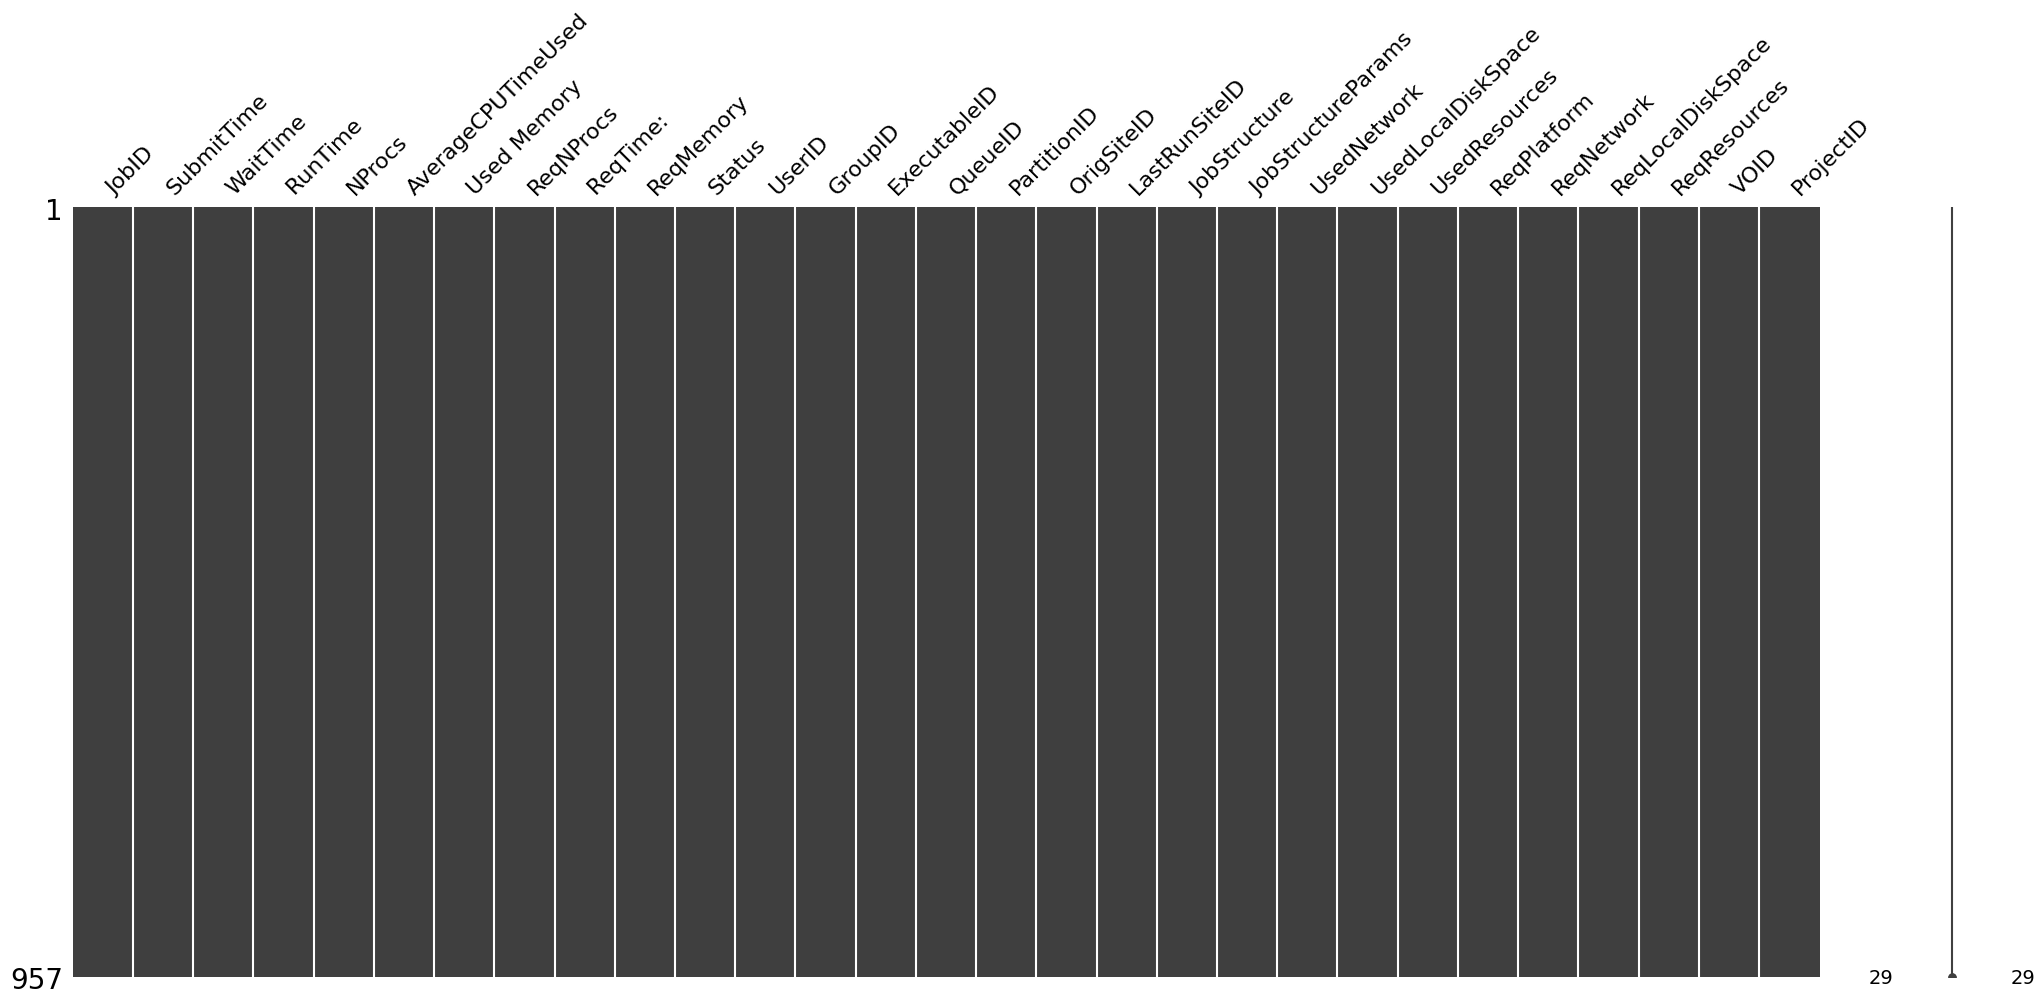

In [107]:
ms.matrix(data)   # Visualize missing values as a matrix plot

In [108]:
data.columns    # List all column names

Index(['JobID', 'SubmitTime', 'WaitTime', 'RunTime ', 'NProcs',
       'AverageCPUTimeUsed', 'Used Memory', 'ReqNProcs', 'ReqTime: ',
       'ReqMemory', 'Status', 'UserID', 'GroupID', 'ExecutableID', 'QueueID',
       'PartitionID', 'OrigSiteID', 'LastRunSiteID', 'JobStructure',
       'JobStructureParams', 'UsedNetwork', 'UsedLocalDiskSpace',
       'UsedResources', 'ReqPlatform', 'ReqNetwork', 'ReqLocalDiskSpace',
       'ReqResources', 'VOID', 'ProjectID'],
      dtype='object')

In [109]:
data['UserID'].value_counts()   # Count frequency of each unique UserID value

,count
UserID,
U2003S1,484
U1021S0,122
U2026S1,113
U1012S0,70
U2015S1,65
U2014S1,32
U5005S3,10
U1033S0,10
U2035S1,7


In [110]:
# Drop irrelevant columns

data.drop(['JobStructure','JobStructureParams','UsedNetwork','UsedLocalDiskSpace','UsedResources','ReqPlatform','ReqNetwork',
          'ReqLocalDiskSpace','ReqResources','VOID','ProjectID'],axis=1,inplace=True)

In [111]:
data.head()   # Display the first 5 rows

,JobID,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,Status,UserID,GroupID,ExecutableID,QueueID,PartitionID,OrigSiteID,LastRunSiteID
0,1,1136070024,203761,138467,1,138371,98652,1,259200,-1,1,U2004S1,G3,X1,Q5,1,clrlcgce02,clrlcgce02
1,2,1136070690,0,11,1,4,35848,1,259200,-1,1,U1023S0,G1,X1,Q1,1,clrlcgce01,clrlcgce01
2,3,1136071207,117,201203,1,0,0,1,259200,-1,1,U2035S1,G6,X1,Q2,1,clrlcgce02,clrlcgce02
3,4,1136071267,4406,196985,1,0,0,1,259200,-1,1,U2035S1,G6,X1,Q2,1,clrlcgce02,clrlcgce02
4,5,1136071269,202516,19520,1,18731,522268,1,259200,-1,1,U2035S1,G6,X1,Q2,1,clrlcgce02,clrlcgce02


In [112]:
data.info()   # Check structure after dropping columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   JobID               957 non-null    int64 
 1   SubmitTime          957 non-null    int64 
 2   WaitTime            957 non-null    int64 
 3   RunTime             957 non-null    int64 
 4   NProcs              957 non-null    int64 
 5   AverageCPUTimeUsed  957 non-null    int64 
 6   Used Memory         957 non-null    int64 
 7   ReqNProcs           957 non-null    int64 
 8   ReqTime:            957 non-null    int64 
 9   ReqMemory           957 non-null    int64 
 10  Status              957 non-null    int64 
 11  UserID              957 non-null    object
 12  GroupID             957 non-null    object
 13  ExecutableID        957 non-null    object
 14  QueueID             957 non-null    object
 15  PartitionID         957 non-null    int64 
 16  OrigSiteID          957 no

## ============================
# 5. Feature Engineering 🛠️
## ============================


Converting Categorical Features

We'll need to convert categorical features to dummy variables using pandas! Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.


In [113]:
# Convert categorical IDs into numeric ranks

data['QueueNO'] = data['QueueID'].rank(method='dense', ascending=False).astype(int)
data['GroupNO'] = data['GroupID'].rank(method='dense', ascending=False).astype(int)
data['ExecutableNO'] = data['ExecutableID'].rank(method='dense', ascending=False).astype(int)
data['OrigSiteNO'] = data['OrigSiteID'].rank(method='dense', ascending=False).astype(int)
data['LastRunSiteNO'] = data['LastRunSiteID'].rank(method='dense', ascending=False).astype(int)
data.head()

,JobID,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,...,ExecutableID,QueueID,PartitionID,OrigSiteID,LastRunSiteID,QueueNO,GroupNO,ExecutableNO,OrigSiteNO,LastRunSiteNO
0,1,1136070024,203761,138467,1,138371,98652,1,259200,-1,...,X1,Q5,1,clrlcgce02,clrlcgce02,5,3,1,2,2
1,2,1136070690,0,11,1,4,35848,1,259200,-1,...,X1,Q1,1,clrlcgce01,clrlcgce01,10,5,1,3,3
2,3,1136071207,117,201203,1,0,0,1,259200,-1,...,X1,Q2,1,clrlcgce02,clrlcgce02,8,1,1,2,2
3,4,1136071267,4406,196985,1,0,0,1,259200,-1,...,X1,Q2,1,clrlcgce02,clrlcgce02,8,1,1,2,2
4,5,1136071269,202516,19520,1,18731,522268,1,259200,-1,...,X1,Q2,1,clrlcgce02,clrlcgce02,8,1,1,2,2


In [114]:
data['USERNO'] = data['UserID'].rank(method='dense', ascending=False).astype(int)
data.head()

,JobID,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,...,QueueID,PartitionID,OrigSiteID,LastRunSiteID,QueueNO,GroupNO,ExecutableNO,OrigSiteNO,LastRunSiteNO,USERNO
0,1,1136070024,203761,138467,1,138371,98652,1,259200,-1,...,Q5,1,clrlcgce02,clrlcgce02,5,3,1,2,2,16
1,2,1136070690,0,11,1,4,35848,1,259200,-1,...,Q1,1,clrlcgce01,clrlcgce01,10,5,1,3,3,21
2,3,1136071207,117,201203,1,0,0,1,259200,-1,...,Q2,1,clrlcgce02,clrlcgce02,8,1,1,2,2,4
3,4,1136071267,4406,196985,1,0,0,1,259200,-1,...,Q2,1,clrlcgce02,clrlcgce02,8,1,1,2,2,4
4,5,1136071269,202516,19520,1,18731,522268,1,259200,-1,...,Q2,1,clrlcgce02,clrlcgce02,8,1,1,2,2,4


In [115]:
data['USERNO']

,USERNO
0,16
1,21
2,4
3,4
4,4
...,...
952,17
953,17
954,17
955,14


In [116]:
# Drop original categorical columns

data.drop(['JobID','UserID','QueueID','GroupID','ExecutableID','OrigSiteID','LastRunSiteID'],axis=1,inplace=True)

In [117]:
data.head()

,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,Status,PartitionID,QueueNO,GroupNO,ExecutableNO,OrigSiteNO,LastRunSiteNO,USERNO
0,1136070024,203761,138467,1,138371,98652,1,259200,-1,1,1,5,3,1,2,2,16
1,1136070690,0,11,1,4,35848,1,259200,-1,1,1,10,5,1,3,3,21
2,1136071207,117,201203,1,0,0,1,259200,-1,1,1,8,1,1,2,2,4
3,1136071267,4406,196985,1,0,0,1,259200,-1,1,1,8,1,1,2,2,4
4,1136071269,202516,19520,1,18731,522268,1,259200,-1,1,1,8,1,1,2,2,4


In [118]:
data.describe()   # Check numeric summary after transformations

,SubmitTime,WaitTime,RunTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,Status,PartitionID,QueueNO,GroupNO,ExecutableNO,OrigSiteNO,LastRunSiteNO,USERNO
count,9.570000e+02,9.570000e+02,957.000000,957.0,957.000000,957.000000,957.0,957.000000,957.000000,957.000000,957.0,957.000000,957.000000,957.0,957.000000,957.000000,957.000000
mean,1.136290e+09,2.747196e+04,16498.660397,1.0,13821.848485,171587.038662,1.0,90174.733542,310730.540230,1.483804,1.0,4.450366,3.705329,1.0,2.222571,2.222571,16.333333
std,3.188653e+04,2.541860e+05,38170.768599,0.0,33469.565043,297369.696069,0.0,100098.401401,307340.823107,1.314944,0.0,2.121047,0.953359,0.0,0.440607,0.440607,5.546180
min,1.136070e+09,0.000000e+00,2.000000,1.0,0.000000,0.000000,1.0,900.000000,-1.000000,0.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
25%,1.136284e+09,1.000000e+00,31.000000,1.0,3.000000,35720.000000,1.0,31980.000000,-1.000000,1.000000,1.0,3.000000,3.000000,1.0,2.000000,2.000000,15.000000
50%,1.136291e+09,1.000000e+00,1850.000000,1.0,8.000000,57528.000000,1.0,31980.000000,614400.000000,1.000000,1.0,5.000000,3.000000,1.0,2.000000,2.000000,17.000000
75%,1.136299e+09,2.000000e+00,1852.000000,1.0,200.000000,152664.000000,1.0,172800.000000,614400.000000,1.000000,1.0,5.000000,5.000000,1.0,2.000000,2.000000,17.000000
max,1.136325e+09,2.629516e+06,259302.000000,1.0,138371.000000,984764.000000,1.0,259200.000000,614400.000000,5.000000,1.0,10.000000,5.000000,1.0,3.000000,3.000000,26.000000


In [119]:
data.loc[data['ReqMemory']== -1].index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       931, 940, 941, 942, 943, 944, 945, 946, 955, 956],
      dtype='int64', length=473)

In [120]:
data.loc[data['ReqTime: ']== -1].index

Index([], dtype='int64')

# **Model Selection**

## ============================
# 6. K‑Nearest Neighbors (KNN)
## ============================

In [121]:
X = data.drop('RunTime ',axis=1)    # Features
y = data['RunTime ']    # Target

In [122]:
from sklearn.model_selection import train_test_split
X1, X2, y1, y2 = train_test_split(X,y, test_size=0.30,random_state=32)
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.30,random_state=32)


In [123]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =================================================================
# 3. SCALE THE 3D FEATURES (X) SAFELY
# =================================================================
scaler_X = StandardScaler()

# FIX 1: Convert Pandas DataFrames safely to NumPy arrays first
X_train_arr = np.asarray(X_train)
X_test_arr = np.asarray(X_test)

# 1. Save the original 3D shapes so we can restore them later
train_shape = X_train_arr.shape
test_shape = X_test_arr.shape

# 2. Flatten the 3D arrays to 2D matrices: [samples * timesteps, features]
X_train_2d = X_train_arr.reshape(-1, train_shape[-1])
X_test_2d = X_test_arr.reshape(-1, test_shape[-1])

# 3. Fit and transform using the 2D matrices
X_train_scaled_2d = scaler_X.fit_transform(X_train_2d)
X_test_scaled_2d = scaler_X.transform(X_test_2d)

# 4. Reshape back into their original 3D shapes (Stored in NEW distinct variables)
X_train = X_train_scaled_2d.reshape(train_shape)
X_test= X_test_scaled_2d.reshape(test_shape)

# =================================================================
# 4. SCALE THE TARGET (y) TO MATCH THE PAPER SCALE (0 to 100)
# =================================================================
scaler_y = MinMaxScaler(feature_range=(0, 100))

# Safe conversion: handle both Pandas Series and raw arrays safely
y_train_2d = np.asarray(y_train).reshape(-1, 1)
y_test_2d = np.asarray(y_test).reshape(-1, 1)

# Fit and transform target matrices (Stored in brand NEW distinct variables!)
y_train = scaler_y.fit_transform(y_train_2d)
y_test= scaler_y.transform(y_test_2d)

# =================================================================
# 5. FINAL UNIFORM VARIABLE ASSIGNMENTS FOR YOUR DOWNSTREAM MODELS
# =================================================================
# FIX 2: Pass the cleanly scaled variables forward to the models
X1 = X_train
y1 = y_train
X2 = X_test
y2 = y_test

print("Preprocessing completed successfully! You can safely run this cell multiple times.")

Preprocessing completed successfully! You can safely run this cell multiple times.


In [124]:
y_train

array([[7.12836456e-01],
       [1.52750669e-01],
       [1.11862864e-02],
       [1.11862864e-02],
       [1.00290843e-02],
       [3.67292070e+01],
       [7.13993659e-01],
       [7.12836456e-01],
       [7.13993659e-01],
       [1.00290843e-02],
       [2.89300510e-02],
       [1.00290843e-02],
       [7.13607925e-01],
       [7.13222191e-01],
       [3.63180145e+01],
       [3.62921704e+01],
       [3.65922714e+01],
       [6.55747823e-03],
       [1.72808838e-01],
       [1.27292224e-02],
       [7.12836456e-01],
       [5.78601020e-03],
       [7.12836456e-01],
       [7.12450722e-01],
       [3.65027811e+01],
       [1.11862864e-02],
       [1.50436265e-02],
       [7.13222191e-01],
       [3.47160612e-03],
       [3.66289162e+01],
       [7.12836456e-01],
       [1.72037370e-01],
       [2.31440408e-03],
       [5.01454217e-03],
       [1.67408562e-01],
       [1.95567145e-01],
       [7.12836456e-01],
       [7.32894625e-03],
       [2.23725728e-02],
       [5.40027619e-03],


In [125]:
X.head()

,SubmitTime,WaitTime,NProcs,AverageCPUTimeUsed,Used Memory,ReqNProcs,ReqTime:,ReqMemory,Status,PartitionID,QueueNO,GroupNO,ExecutableNO,OrigSiteNO,LastRunSiteNO,USERNO
0,1136070024,203761,1,138371,98652,1,259200,-1,1,1,5,3,1,2,2,16
1,1136070690,0,1,4,35848,1,259200,-1,1,1,10,5,1,3,3,21
2,1136071207,117,1,0,0,1,259200,-1,1,1,8,1,1,2,2,4
3,1136071267,4406,1,0,0,1,259200,-1,1,1,8,1,1,2,2,4
4,1136071269,202516,1,18731,522268,1,259200,-1,1,1,8,1,1,2,2,4


====== KNN Regression Report ======
MAE    : 0.8583
RMSE   : 5.4181
RAE    : 0.0789
CC     : 0.9366
NRMSE  : 0.7669
SMAPE% : 13.10%
R^2    : 0.8760


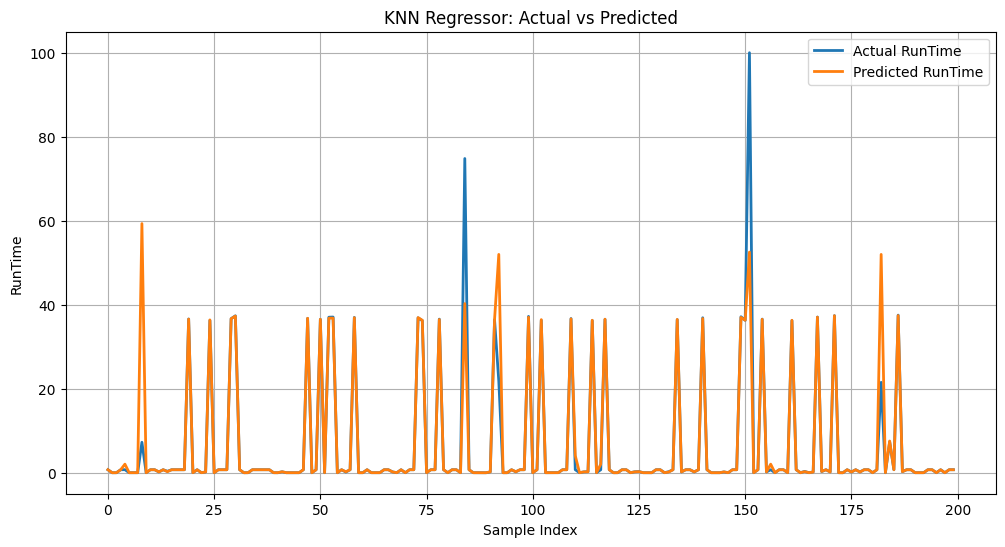

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model_metrics = []
# -----------------------------
# 1) KNN Regressor
# -----------------------------
knn = KNeighborsRegressor(n_neighbors=4)

# -----------------------------
# 2) Train
# -----------------------------
knn.fit(X_train, y_train)

# -----------------------------
# 3) Predict
# -----------------------------
y_pred_knn = knn.predict(X_test)

# -----------------------------
# 4) Metrics
# -----------------------------
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred_knn).ravel()
eps = 1e-9

mae_knn  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse_knn = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

# RAE
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# CC (Pearson correlation)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# NRMSE (mean)
nrmse = rmse_knn / (np.mean(np.abs(y_true)) + eps)

# SMAPE (%)
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("====== KNN Regression Report ======")
print(f"MAE    : {mae_knn:.4f}")
print(f"RMSE   : {rmse_knn:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("===================================")

model_metrics.append({
    'Model': 'KNN',
    'MAE': mae_knn,
    'RAE': rae,
    'RMSE': rmse_knn,
    'R2': r2,
    'CC': cc,
    'prediction': y_pred_knn
})

# -----------------------------
# 5) Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("KNN Regressor: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

In [127]:
knn.score(X_train, y_train)

0.9388073160137779

In [128]:
y_pred

array([7.13029323e-01, 2.21797058e-03, 1.09934194e-02, 7.13607925e-01,
       2.04062936e+00, 1.02219514e-02, 9.64335033e-03, 1.09934194e-02,
       5.93254091e+01, 6.75034523e-03, 7.13607925e-01, 7.13222191e-01,
       1.96049312e-01, 7.14668693e-01, 2.58731089e-01, 7.13318624e-01,
       7.13125757e-01, 7.13125757e-01, 7.13607925e-01, 3.65854247e+01,
       1.47543260e-02, 7.12932890e-01, 9.25761632e-03, 1.73580306e-01,
       3.63924612e+01, 8.58258179e-03, 7.13318624e-01, 7.13125757e-01,
       7.13125757e-01, 3.66831118e+01, 3.73059758e+01, 7.13029323e-01,
       2.21797058e-03, 9.93265084e-03, 7.13511491e-01, 7.13511491e-01,
       7.13125757e-01, 7.13029323e-01, 7.12932890e-01, 1.07041189e-02,
       1.09934194e-02, 2.28258102e-01, 8.87188230e-03, 7.52181326e-03,
       7.03964574e-03, 9.93265084e-03, 7.13222191e-01, 3.67835955e+01,
       2.31440408e-03, 7.13029323e-01, 3.65422224e+01, 1.06076854e-02,
       3.68140685e+01, 3.68140685e+01, 2.21797058e-03, 7.13125757e-01,
      

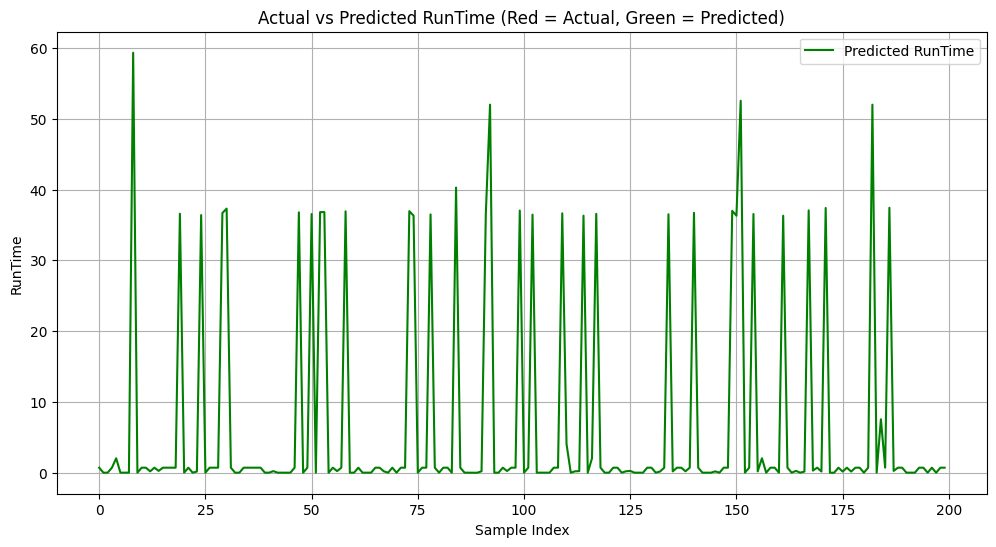

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_pred[:200], color='green', label='Predicted RunTime')        # Green

plt.legend()
plt.title("Actual vs Predicted RunTime (Red = Actual, Green = Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.grid(True)
plt.show()


====== Random Forest Regression Report ======
MAE    : 0.7205
RMSE   : 5.2904
RAE    : 0.0663
CC     : 0.9393
NRMSE  : 0.7489
SMAPE% : 14.29%
R^2    : 0.8818


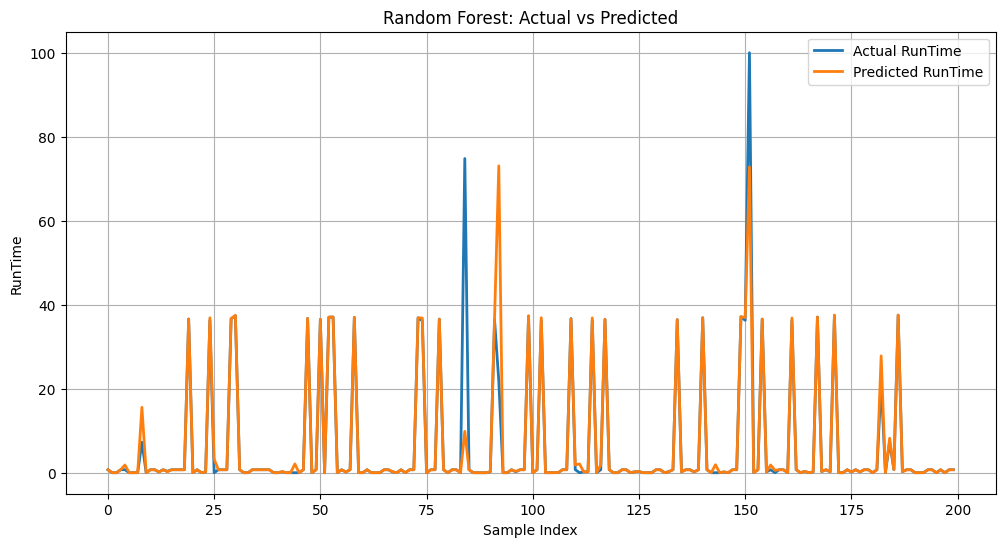

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Instantiate Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_reg.predict(X_test)

# -----------------------------
# Metrics (added)
# -----------------------------
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred_rf).ravel()
eps = 1e-9

mae_rf  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse_rf = np.sqrt(mse)
r2_rf   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse_rf / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("====== Random Forest Regression Report ======")
print(f"MAE    : {mae_rf:.4f}")
print(f"RMSE   : {rmse_rf:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2_rf:.4f}")
print("===========================================")

model_metrics.append({
    'Model': 'Random Forest',
    'RAE': rae,
    'MAE': mae_rf,
    'RMSE': rmse_rf,
    'R2': r2_rf,
    'CC': cc,
    'prediction': y_pred_rf
})

# -----------------------------
# Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

## ============================
# 10. Decision Tree Regressor
## ============================

====== Decision Tree Regression Report ======
MAE    : 0.6218
RMSE   : 6.4809
RAE    : 0.0572
CC     : 0.9139
NRMSE  : 0.9174
SMAPE% : 9.97%
R^2    : 0.8226


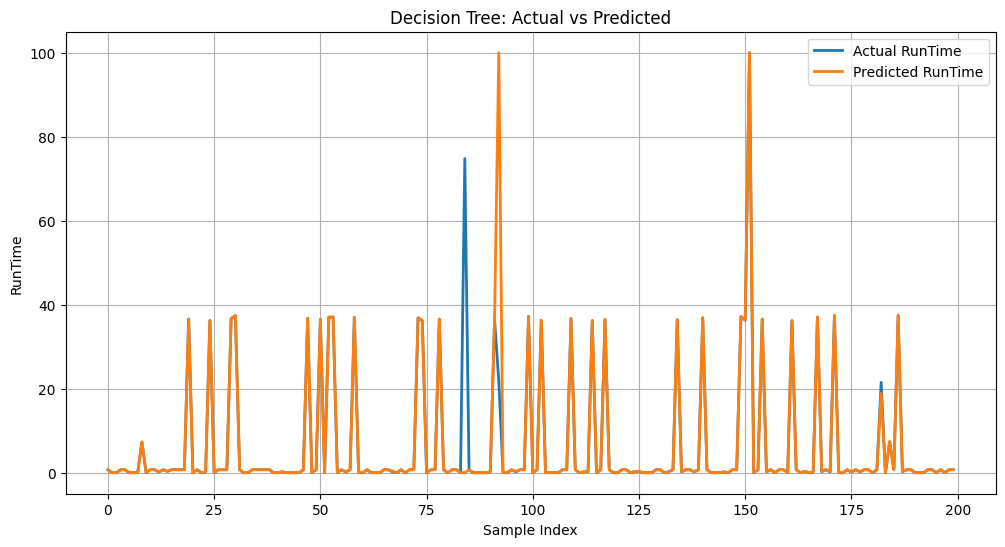

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Instantiate Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)

# Train the model
dt_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_reg.predict(X_test)

# -----------------------------
# Metrics (added)
# -----------------------------
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred_dt).ravel()
eps = 1e-9

mae_dt  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse_dt = np.sqrt(mse)
r2_dt   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse_dt / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("====== Decision Tree Regression Report ======")
print(f"MAE    : {mae_dt:.4f}")
print(f"RMSE   : {rmse_dt:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2_dt:.4f}")
print("============================================")


model_metrics.append({
    'Model': 'Decision Tree',
    'RAE': rae,
    'MAE': mae_dt,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})


# -----------------------------
# Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

In [132]:
y_pred_dt

array([7.13222191e-01, 2.31440408e-03, 1.04148184e-02, 7.12836456e-01,
       7.13607925e-01, 9.64335033e-03, 1.00290843e-02, 1.15720204e-02,
       7.38333475e+00, 5.78601020e-03, 7.13607925e-01, 7.12836456e-01,
       1.84380858e-01, 7.15536595e-01, 2.88143308e-01, 7.12836456e-01,
       7.12836456e-01, 7.13222191e-01, 7.13607925e-01, 3.65814709e+01,
       1.04148184e-02, 7.12450722e-01, 1.11862864e-02, 1.96724347e-01,
       3.61988227e+01, 3.47160612e-03, 7.12450722e-01, 7.12836456e-01,
       7.13993659e-01, 3.66840761e+01, 3.74744451e+01, 7.13222191e-01,
       2.31440408e-03, 1.08005524e-02, 7.15150861e-01, 7.13222191e-01,
       7.12836456e-01, 7.12836456e-01, 7.12450722e-01, 1.15720204e-02,
       3.85734013e-03, 2.31440408e-01, 1.04148184e-02, 1.11862864e-02,
       6.55747823e-03, 9.64335033e-03, 7.12836456e-01, 3.67535083e+01,
       1.92867007e-03, 7.13222191e-01, 3.65182105e+01, 1.08005524e-02,
       3.70601668e+01, 3.70856252e+01, 1.92867007e-03, 7.13607925e-01,
      

## ============================
# 7. Linear Regression
## ============================

====== Linear Regression Report ======
MAE    : 2.2937
RMSE   : 6.8061
RAE    : 0.2110
CC     : 0.8980
NRMSE  : 0.9634
SMAPE% : 101.48%
R^2    : 0.8043


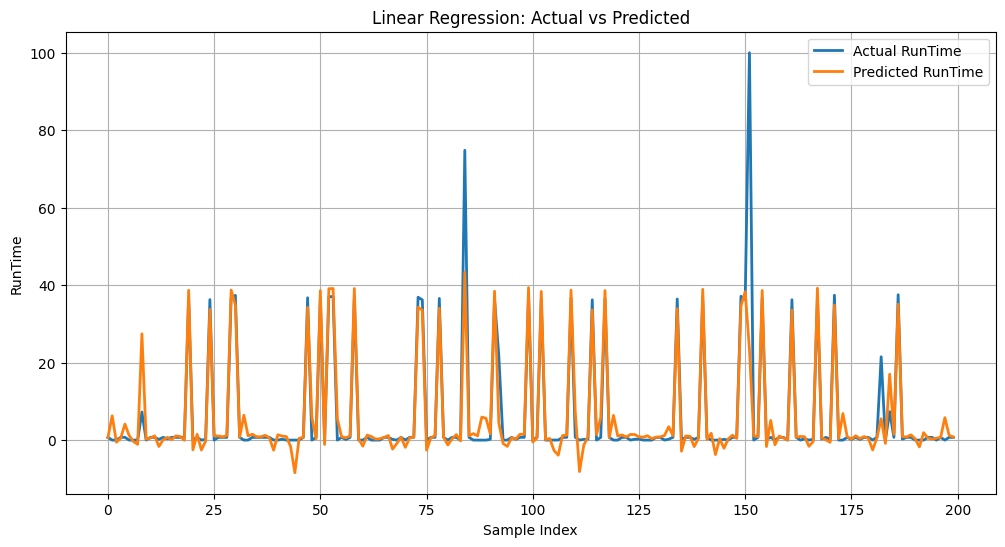

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Train regression model
reg = LinearRegression().fit(X_train, y_train)

# Predict test set
y_pred_lin_reg = reg.predict(X_test)

# -----------------------------
# Metrics (added)
# -----------------------------
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred_lin_reg).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

# RAE
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# CC (Pearson correlation)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# NRMSE (mean)
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

# SMAPE (%)
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("====== Linear Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("=====================================")

model_metrics.append({
    'Model': 'Linear Regression',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC':cc,
    'prediction': y_pred_lin_reg
})

# -----------------------------
# Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

## ============================
# 8. Support Vector Classifier (SVC)
## ============================

In [134]:
from sklearn import preprocessing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# FIX 1: Import SVR (Regression) instead of SVC (Classification)
from sklearn.svm import SVR

# Initialize Support Vector Regression with a linear kernel
regressor_svr = SVR(kernel='linear')

# FIX 2: Fit using your scaled training data matrices
regressor_svr.fit(X_train, y_train.ravel()) # .ravel() flattens the 2D array to a 1D vector for training

# FIX 3: Predict using your scaled features matrix
y_pred_svr = regressor_svr.predict(X_test)

# FIX 4: Compute evaluation metrics against the scaled test labels
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

# FIX 5: Calculate True RAE (Relative Absolute Error) matching your paper format
mean_baseline = np.mean(y_test)
rae_svr = np.sum(np.abs(y_test.ravel() - y_pred_svr)) / np.sum(np.abs(y_test.ravel() - mean_baseline))

# FIX 6: Calculate CC (Correlation Coefficient)
cc_svr = np.corrcoef(y_test.ravel(), y_pred_svr)[0, 1]

# Print Report
print(f"====== SVR Regression Report ======")
print(f"MAE    : {mae_svr:.4f}")
print(f"RMSE   : {rmse_svr:.4f}")
print(f"R^2    : {r2_svr:.4f}")
print(f"RAE    : {rae_svr:.4f}")
print(f"CC     : {cc_svr:.4f}")
print(f"====================================")

# Append clean metrics to your comparison log list
model_metrics.append({
    'Model': 'Support Vector Regression (SVR)',
    'MAE': mae_svr,
    'RMSE': rmse_svr,
    'R2': r2_svr,
    'RAE': rae_svr,
    'CC': cc_svr,
    'Prediction': y_pred_svr
})

====== SVR Regression Report ======
MAE    : 0.8072
RMSE   : 7.2500
R^2    : 0.7780
RAE    : 0.0742
CC     : 0.8836


## ============================
# 11. Hybrid Model
## ============================

====== Hybrid (VotingRegressor) Report ======
MAE    : 1.0403
RMSE   : 4.6655
RAE    : 0.0957
CC     : 0.9530
NRMSE  : 0.6604
SMAPE% : 81.80%
R^2    : 0.9081
Hybrid Model Predicted Burst Time for Input: 0.6923


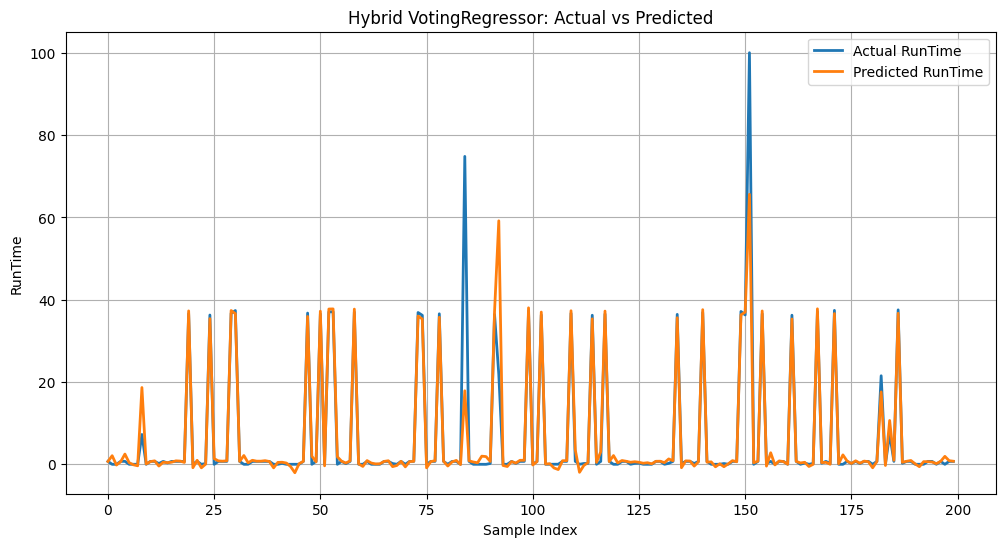

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Define the individual models
model1 = LinearRegression()
model2 = DecisionTreeRegressor(random_state=42)
model3 = RandomForestRegressor(n_estimators=50, random_state=42)

# 2. Create the Hybrid (Ensemble) Model
hybrid_model = VotingRegressor(estimators=[
    ('lr', model1),
    ('dt', model2),
    ('rf', model3)
])

# 3. Train the Hybrid Model
hybrid_model.fit(X_train, y_train)

# 4. Predict on test set
y_pred = hybrid_model.predict(X_test)

# -----------------------------
# Metrics (added)
# -----------------------------
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("====== Hybrid (VotingRegressor) Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("=============================================")


# 5. Use the hybrid model for your scheduling engine prediction
hybrid_prediction = hybrid_model.predict(X_test)
print(f"Hybrid Model Predicted Burst Time for Input: {hybrid_prediction[0]:.4f}")
model_metrics.append({
    'Model': 'Hybrid (VotingRegressor)',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC':cc,
    'Prediction': hybrid_prediction

})

# -----------------------------
# Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("Hybrid VotingRegressor: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

============================
# 12 . XGBoost Model (097)
============================

====== XGBoost Regression Report ======
R2 Score   : 0.9404
MAE        : 0.6718
MSE        : 14.1134
RAE        :   0.0957
RMSE       : 3.7568
MAPE (%)   : 697.97%
NMAE       : 0.0951
CC         : 0.9698


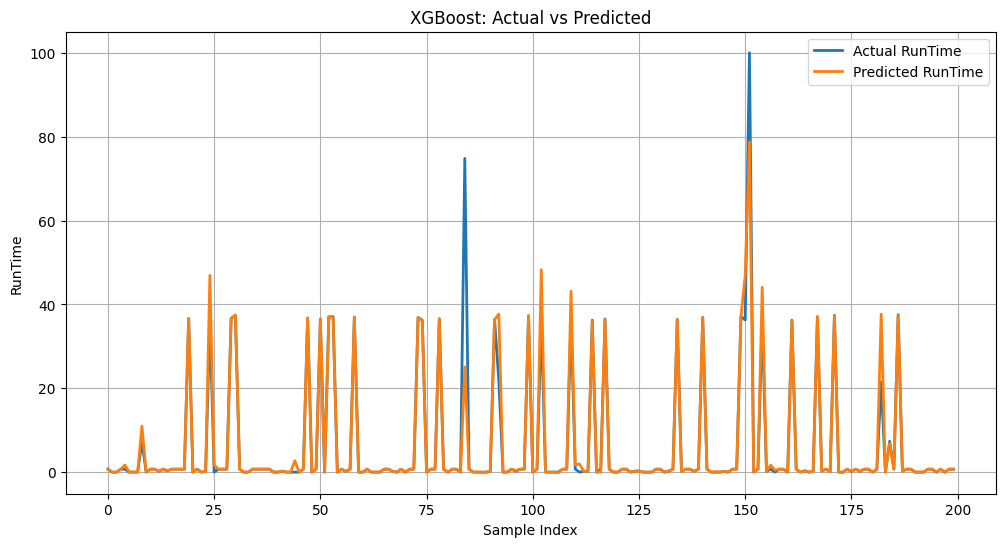

In [136]:
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# -----------------------------
# 1) Initialize XGBoost model
# -----------------------------
xgb_reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# -----------------------------
# 2) Train
# -----------------------------
xgb_reg.fit(X_train, y_train)

# -----------------------------
# 3) Predict
# -----------------------------
xgb_pred = xgb_reg.predict(X_test)

# -----------------------------
# 4) Metrics / Errors
# -----------------------------
mse  = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, xgb_pred)
r2   = r2_score(y_test, xgb_pred)

# Optional (be careful if y_test has zeros)
mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100

# Extra useful metric
nmae = mae / (np.mean(np.abs(y_test)) + 1e-9)

# ✅ CC (Correlation Coefficient) = Pearson correlation
cc = np.corrcoef(np.asarray(y_test).ravel(), np.asarray(xgb_pred).ravel())[0, 1]

print("====== XGBoost Regression Report ======")
print(f"R2 Score   : {r2:.4f}")
print(f"MAE        : {mae:.4f}")
print(f"MSE        : {mse:.4f}")
print(f"RAE        :  {rae: .4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"MAPE (%)   : {mape:.2f}%")
print(f"NMAE       : {nmae:.4f}")
print(f"CC         : {cc:.4f}")
print("=======================================")

model_metrics.append({
    'Model': 'XGBoost',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC':cc,
    'prediction': xgb_pred
})

# -----------------------------
# 7) Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))

# if y_test is pandas Series -> y_test.values works, else np.asarray works too
y_true_plot = np.asarray(y_test).ravel()
plt.plot(y_true_plot[:200], label="Actual RunTime", linewidth=2)
plt.plot(xgb_pred[:200], label="Predicted RunTime", linewidth=2)

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

===========================
# 13. CatBoost Model (097)
===========================

0:	learn: 13.8071922	total: 11ms	remaining: 22s
200:	learn: 0.4732448	total: 1.44s	remaining: 12.9s
400:	learn: 0.0955028	total: 2.87s	remaining: 11.4s
600:	learn: 0.0401826	total: 4.6s	remaining: 10.7s
800:	learn: 0.0229815	total: 6.39s	remaining: 9.57s
1000:	learn: 0.0151601	total: 7.81s	remaining: 7.8s
1200:	learn: 0.0114475	total: 9.34s	remaining: 6.22s
1400:	learn: 0.0089598	total: 11.3s	remaining: 4.82s
1600:	learn: 0.0073140	total: 12.8s	remaining: 3.18s
1800:	learn: 0.0062044	total: 13.9s	remaining: 1.54s
1999:	learn: 0.0054673	total: 15.2s	remaining: 0us
====== CatBoost Regression Report ======
R2 Score       : 0.8743
MAE            : 0.7067
MSE            : 29.7572
RMSE           : 5.4550
RAE            : 0.0650
CC             : 0.9395
NRMSE (mean)   : 0.7722
MAPE (safe) %  : 1514.32%   (ignores y=0)
SMAPE %        : 39.47%
WMAPE %        : 10.00%
y_test near-zero count: 0 / 288
CatBoost Predicted Burst Time for Input: 0.7177


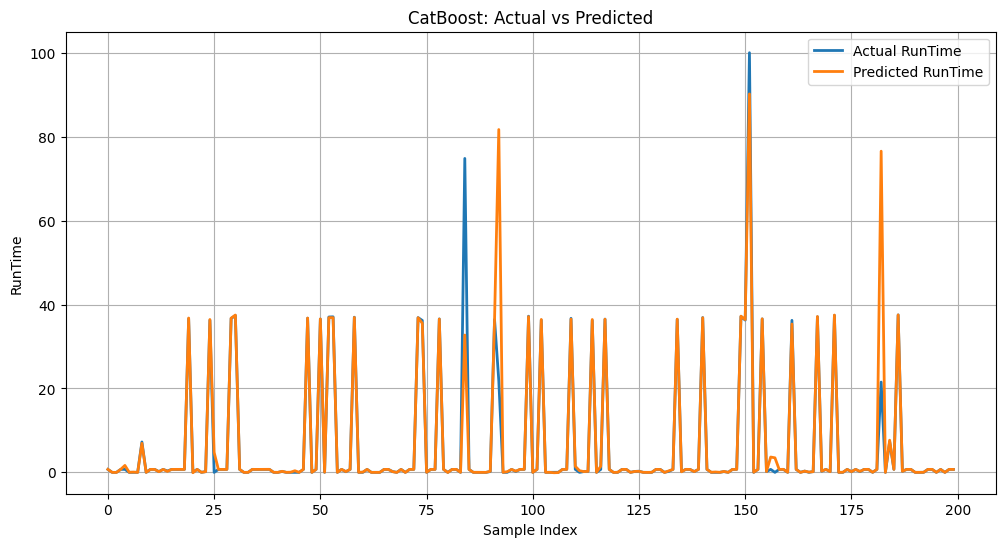

In [137]:
!pip install -q catboost

import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1) Initialize CatBoost model
# -----------------------------
cat_reg = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

# -----------------------------
# 2) Train
# -----------------------------
cat_reg.fit(X_train, y_train)

# -----------------------------
# 3) Predict
# -----------------------------
cat_pred = cat_reg.predict(X_test)

# -----------------------------
# 4) Metrics / Errors (Improved)
# -----------------------------
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(cat_pred).ravel()

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

eps = 1e-9
mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

wmape = (np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps)) * 100
nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

# ✅ CC (Correlation Coefficient) = Pearson correlation
cc = np.corrcoef(y_true, y_pred)[0, 1]

# ✅ RAE (Relative Absolute Error) like many result tables:
# sum(|y - yhat|) / sum(|y - mean(y)|)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

print("====== CatBoost Regression Report ======")
print(f"R2 Score       : {r2:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MSE            : {mse:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"RAE            : {rae:.4f}")
print(f"CC             : {cc:.4f}")
print(f"NRMSE (mean)   : {nrmse_mean:.4f}")
print(f"MAPE (safe) %  : {mape_safe:.2f}%   (ignores y=0)")
print(f"SMAPE %        : {smape:.2f}%")
print(f"WMAPE %        : {wmape:.2f}%")
print("=======================================")

zeros = np.sum(np.abs(y_true) <= eps)
print(f"y_test near-zero count: {zeros} / {len(y_true)}")

print(f"CatBoost Predicted Burst Time for Input: {y_pred[0]:.4f}")


model_metrics.append({
    'Model': 'CatBoost Model',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})

# -----------------------------
# 5) Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("CatBoost: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

============================
# 14 LightGBM  model (097)
============================

In [138]:
!pip install lightgbm

====== LightGBM Regression Report ======
R2 Score       : 0.8900
MAE            : 1.4528
MSE            : 26.0500
RMSE           : 5.1039
RAE            : 0.1336
CC             : 0.9440
NRMSE (mean)   : 0.7225
MAPE (safe) %  : 2989.63%
SMAPE %        : 85.54%
WMAPE %        : 20.56%
LightGBM Predicted Burst Time for Input: 0.6806


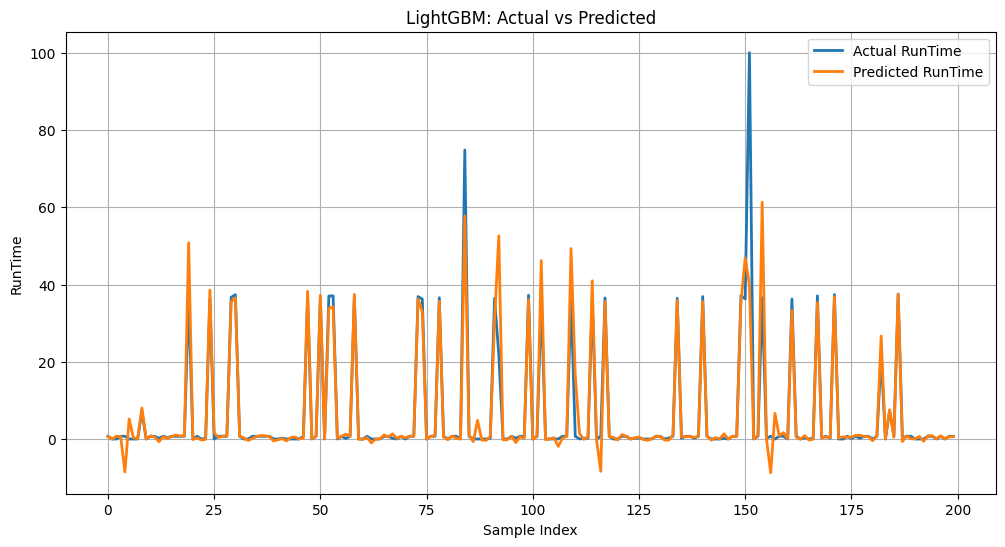

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# -----------------------------
# 0) Clean column names (remove special characters)
# -----------------------------
# If X_train and X_test are DataFrames, we sanitise their column names
def clean_column_names(df):
    # Replace spaces, colons, parentheses, and other special chars with underscore
    df = df.copy()
    df.columns = df.columns.str.replace(r'[^\w]', '_', regex=True)
    # Also strip trailing underscores and ensure no duplicate names (rare)
    df.columns = df.columns.str.strip('_')
    return df

# Apply to both train and test sets
if isinstance(X_train, pd.DataFrame):
    X_train_clean = clean_column_names(X_train)
    X_test_clean = clean_column_names(X_test)
else:
    # If not DataFrame, keep as is (maybe numpy array) – no rename needed
    X_train_clean = X_train
    X_test_clean = X_test

# -----------------------------
# 1) Initialize LightGBM model
# -----------------------------
lgbm_reg = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# -----------------------------
# 2) Train (silent mode)
# -----------------------------
lgbm_reg.fit(X_train_clean, y_train)

# -----------------------------
# 3) Predict
# -----------------------------
lgbm_pred = lgbm_reg.predict(X_test_clean)

# -----------------------------
# 4) Metrics / Errors
# -----------------------------
y_true = np.array(y_test).ravel()
y_pred = np.array(lgbm_pred).ravel()

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

eps = 1e-9

mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

smape = np.mean(
    2 * np.abs(y_pred - y_true) /
    (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

wmape = (np.sum(np.abs(y_true - y_pred)) /
         (np.sum(np.abs(y_true)) + eps)) * 100

nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# RAE (Relative Absolute Error)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

print("====== LightGBM Regression Report ======")
print(f"R2 Score       : {r2:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MSE            : {mse:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"RAE            : {rae:.4f}")
print(f"CC             : {cc:.4f}")
print(f"NRMSE (mean)   : {nrmse_mean:.4f}")
print(f"MAPE (safe) %  : {mape_safe:.2f}%")
print(f"SMAPE %        : {smape:.2f}%")
print(f"WMAPE %        : {wmape:.2f}%")
print("=======================================")

print(f"LightGBM Predicted Burst Time for Input: {y_pred[0]:.4f}")

# Append to model_metrics (ensure the list exists)
if 'model_metrics' not in globals():
    model_metrics = []
model_metrics.append({
    'Model': 'LightGBM',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC':cc,
    'prediction': y_pred
})

# -----------------------------
# 5) Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("LightGBM: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

========================
# 15 sarimax Model (097)
========================

====== SARIMAX Forecasting Report ======
SARIMAX order        : (1, 1, 1)
Seasonal order       : (0, 0, 0, 0)
R2 Score             : 0.7960
MAE                  : 2.3241
MSE                  : 48.2969
RMSE                 : 6.9496
RAE                  : 0.2138
CC                   : 0.8938
NRMSE (mean)         : 0.9837
MAPE (safe) %        : 15817.60%   (ignores y=0)
SMAPE %              : 99.86%
WMAPE %              : 32.90%
y_test near-zero count: 0 / 288
SARIMAX Predicted Burst Time for Input: 0.7134


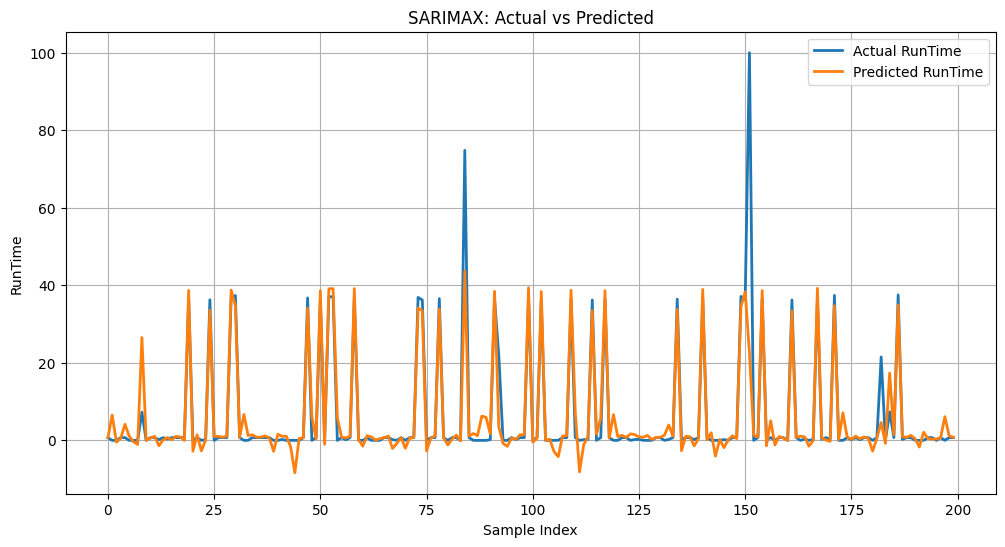

In [140]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Silence statsmodels warnings/logs
warnings.filterwarnings("ignore")

# -----------------------------
# 0) Ensure numpy arrays
# -----------------------------
y_train_arr = np.asarray(y_train).astype(float).ravel()
y_test_arr  = np.asarray(y_test).astype(float).ravel()

# SARIMAX needs exogenous arrays to be 2D
X_train_arr = np.asarray(X_train)
X_test_arr  = np.asarray(X_test)

if X_train_arr.ndim == 1:
    X_train_arr = X_train_arr.reshape(-1, 1)
if X_test_arr.ndim == 1:
    X_test_arr = X_test_arr.reshape(-1, 1)

# -----------------------------
# 1) Set SARIMAX order
#    (You can change these)
# -----------------------------
order = (1, 1, 1)          # (p,d,q)
seasonal_order = (0, 0, 0, 0)  # (P,D,Q,s) keep 0 if no seasonality

# -----------------------------
# 2) Train SARIMAX (with exog)
# -----------------------------
model = SARIMAX(
    endog=y_train_arr,
    exog=X_train_arr,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)   # disp=False removes optimizer output

# -----------------------------
# 3) Predict on test (with exog)
# -----------------------------
y_pred = fit.predict(
    start=len(y_train_arr),
    end=len(y_train_arr) + len(y_test_arr) - 1,
    exog=X_test_arr
)

y_true = y_test_arr
y_pred = np.asarray(y_pred).astype(float).ravel()

# -----------------------------
# 4) Metrics (same style)
# -----------------------------
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

eps = 1e-9

mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

wmape = (np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps)) * 100
nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

zeros = np.sum(np.abs(y_true) <= eps)

# ✅ CC (Correlation Coefficient) = Pearson correlation
cc = np.corrcoef(y_true, y_pred)[0, 1]

# ✅ RAE (Relative Absolute Error)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

print("====== SARIMAX Forecasting Report ======")
print(f"SARIMAX order        : {order}")
print(f"Seasonal order       : {seasonal_order}")
print(f"R2 Score             : {r2:.4f}")
print(f"MAE                  : {mae:.4f}")
print(f"MSE                  : {mse:.4f}")
print(f"RMSE                 : {rmse:.4f}")
print(f"RAE                  : {rae:.4f}")
print(f"CC                   : {cc:.4f}")
print(f"NRMSE (mean)         : {nrmse_mean:.4f}")
print(f"MAPE (safe) %        : {mape_safe:.2f}%   (ignores y=0)" if not np.isnan(mape_safe) else "MAPE (safe) %        : NaN (all y=0)")
print(f"SMAPE %              : {smape:.2f}%")
print(f"WMAPE %              : {wmape:.2f}%")
print("=======================================")
print(f"y_test near-zero count: {zeros} / {len(y_true)}")
print(f"SARIMAX Predicted Burst Time for Input: {y_pred[0]:.4f}")

# -----------------------------
# 5) Plot Actual vs Predicted
# -----------------------------

model_metrics.append({
    'Model': 'sarimax Model ',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})

plt.figure(figsize=(12, 6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("SARIMAX: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime")
plt.legend()
plt.grid(True)
plt.show()

==================
# 16. DQN (097)
=================

In [141]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------- ENV ----------------
class Env:
    def __init__(self):
        self.th = 50

    def reset(self):
        self.burst = np.random.randint(1,101)
        return np.array([self.burst/100],dtype=np.float32)

    def step(self,a):
        correct = 0 if self.burst < self.th else 1
        r = 1 if a==correct else -1
        return np.array([self.burst/100],dtype=np.float32), r, True, {"burst":self.burst}

# ---------------- MODEL ----------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(1,32),
            nn.ReLU(),
            nn.Linear(32,2)
        )
    def forward(self,x):
        return self.fc(x)

# ---------------- METRICS ----------------
def metrics(y,yhat):

    y=np.array(y); yhat=np.array(yhat)

    mae=np.mean(np.abs(y-yhat))
    rmse=np.sqrt(np.mean((y-yhat)**2))
    rae=np.sum(np.abs(y-yhat))/np.sum(np.abs(y-np.mean(y)))
    cc=np.corrcoef(y,yhat)[0,1]
    nrmse=rmse/(np.max(y)-np.min(y))
    smape=np.mean(2*np.abs(yhat-y)/(np.abs(y)+np.abs(yhat)+1e-8))*100
    r2=1-np.sum((y-yhat)**2)/np.sum((y-np.mean(y))**2)

    return mae,rmse,rae,cc,nrmse,smape,r2

# ---------------- TRAIN ----------------
env=Env()
model=Net()
opt=optim.Adam(model.parameters(),lr=0.01)
loss_fn=nn.MSELoss()

for ep in range(2000):

    s=env.reset()
    s=torch.tensor(s).unsqueeze(0)

    if random.random()<0.1:
        a=random.randint(0,1)
    else:
        a=torch.argmax(model(s)).item()

    _,r,_,_=env.step(a)

    q=model(s)[0,a]
    target=torch.tensor(float(r))

    loss=loss_fn(q,target)

    opt.zero_grad()
    loss.backward()
    opt.step()

# ---------------- TEST ----------------
y=[]
yhat=[]
correct=0

for _ in range(500):

    s=env.reset()
    s_t=torch.tensor(s).unsqueeze(0)

    a=torch.argmax(model(s_t)).item()
    _,r,_,info=env.step(a)

    correct+=1 if r>0 else 0

    y.append(info["burst"])
    yhat.append(0 if a==0 else 100)

# metrics
mae,rmse,rae,cc,nrmse,smape,r2=metrics(y,yhat)

model_metrics.append({
    'Model': 'DQN',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})

print("\nAccuracy:",correct/500)
print("MAE:",mae)
print("RMSE:",rmse)
print("RAE:",rae)
print("CC:",cc)
print("NRMSE:",nrmse)
print("SMAPE:",smape)
print("R2:",r2)


Accuracy: 0.974
MAE: 25.676
RMSE: 29.5899983102399
RAE: 1.051975005637629
CC: 0.8558628300831144
NRMSE: 0.29888887182060503
SMAPE: 107.8360317433828
R2: -0.08684029312573038


==================
# 17. Multiple Linear Regression Model (053)
=================

In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# 3) Initialize Multiple Linear Regression
# -----------------------------
mlr_model = LinearRegression()

# -----------------------------
# 4) Train Model
# -----------------------------
mlr_model.fit(X_train, y_train)

# -----------------------------
# 5) Predict
# -----------------------------
mlr_pred = mlr_model.predict(X_test)

# -----------------------------
# 6) Evaluation Metrics
# -----------------------------
mse  = mean_squared_error(y_test, mlr_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, mlr_pred)
r2   = r2_score(y_test, mlr_pred)

# ✅ ADDED metrics (table-style)
eps = 1e-9
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(mlr_pred).ravel()

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# RAE (Relative Absolute Error)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# NRMSE (mean)
nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

# SMAPE (%)
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

# Optional safe MAPE (%)
mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

print("====== Multiple Linear Regression Report ======")
print(f"R2 Score     : {r2:.4f}")
print(f"MAE          : {mae:.4f}")
print(f"MSE          : {mse:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"RAE          : {rae:.4f}")
print(f"CC           : {cc:.4f}")
print(f"NRMSE (mean) : {nrmse_mean:.4f}")
print(f"SMAPE %      : {smape:.2f}%")
print(f"MAPE (safe)% : {mape_safe:.2f}%" if not np.isnan(mape_safe) else "MAPE (safe)% : NaN (all y=0)")
print("================================================")

model_metrics.append({
    'Model': 'Multiple Linear Regression Model',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})


====== Multiple Linear Regression Report ======
R2 Score     : 0.8043
MAE          : 2.2937
MSE          : 46.3236
RMSE         : 6.8061
RAE          : 0.2110
CC           : 0.8980
NRMSE (mean) : 0.9634
SMAPE %      : 101.48%
MAPE (safe)% : 15100.37%


# ============================
# 18. Exponential Moving Average (EMA) Model (053)
# ============================

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------
# 3) Apply Exponential Moving Average
# -----------------------------
alpha = 0.3   # smoothing factor (0 < alpha <= 1)

# FIX 1: Wrap y_train in pd.Series so it can use .ewm() safely
ema_train = pd.Series(y_train.ravel()).ewm(alpha=alpha, adjust=False).mean()

# Forecasting:
# last EMA value used as starting prediction
ema_predictions = []

# FIX 2: Use native index [-1] since ema_train is a clean 1D vector series now
last_ema = ema_train.values[-1]

for actual in y_test.ravel():
    last_ema = alpha * actual + (1 - alpha) * last_ema
    ema_predictions.append(last_ema)

ema_predictions = np.array(ema_predictions)

# -----------------------------
# 4) Evaluation Metrics
# -----------------------------
mse  = mean_squared_error(y_test, ema_predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, ema_predictions)
r2   = r2_score(y_test, ema_predictions)

# Setup metrics arrays
eps = 1e-9
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(ema_predictions).ravel()

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# RAE (Relative Absolute Error)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# NRMSE (mean)
nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

# SMAPE (%)
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

# Optional safe MAPE (%)
mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

print("====== EMA Model Report ======")
print(f"Alpha        : {alpha}")
print(f"R2 Score     : {r2:.4f}")
print(f"MAE          : {mae:.4f}")
print(f"MSE          : {mse:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"RAE          : {rae:.4f}")
print(f"CC           : {cc:.4f}")
print(f"NRMSE (mean) : {nrmse_mean:.4f}")
print(f"SMAPE %      : {smape:.2f}%")
print(f"MAPE (safe)% : {mape_safe:.2f}%" if not np.isnan(mape_safe) else "MAPE (safe)% : NaN (all y=0)")
print("================================")

# FIX 3: Replaced '_dt' typos with the actual computed EMA metrics variables
model_metrics.append({
    'Model': 'Exponential Moving Average (EMA) Model',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

====== EMA Model Report ======
Alpha        : 0.3
R2 Score     : 0.4245
MAE          : 7.6984
MSE          : 136.2525
RMSE         : 11.6727
RAE          : 0.7081
CC           : 0.7147
NRMSE (mean) : 1.6523
SMAPE %      : 139.07%
MAPE (safe)% : 32521.68%


# ============================
# 19. Moving Average (MA) Model (053)
# ============================

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------
# 3) Apply Moving Average
# -----------------------------
window_size = 5   # number of previous samples used

# FIX 1: Wrap y_train in pd.Series to use .rolling() safely
ma_train = pd.Series(y_train.ravel()).rolling(window=window_size).mean()

# Forecasting:
# FIX 2: Convert y_train directly to a list without calling non-existent '.values'
history = list(y_train.ravel())
ma_predictions = []

for actual in y_test.ravel():
    if len(history) >= window_size:
        prediction = np.mean(history[-window_size:])
    else:
        prediction = np.mean(history)

    ma_predictions.append(prediction)
    history.append(actual)  # update history with real value

ma_predictions = np.array(ma_predictions)

# -----------------------------
# 4) Evaluation Metrics
# -----------------------------
mse  = mean_squared_error(y_test, ma_predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, ma_predictions)
r2   = r2_score(y_test, ma_predictions)

# Setup metrics arrays
eps = 1e-9
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(ma_predictions).ravel()

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# RAE (Relative Absolute Error)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# NRMSE (mean)
nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

# SMAPE (%)
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

# Optional safe MAPE (%)
mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

print("====== Moving Average (MA) Report ======")
print(f"Window Size  : {window_size}")
print(f"R2 Score     : {r2:.4f}")
print(f"MAE          : {mae:.4f}")
print(f"MSE          : {mse:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"RAE          : {rae:.4f}")
print(f"CC           : {cc:.4f}")
print(f"NRMSE (mean) : {nrmse_mean:.4f}")
print(f"SMAPE %      : {smape:.2f}%")
print(f"MAPE (safe)% : {mape_safe:.2f}%" if not np.isnan(mape_safe) else "MAPE (safe)% : NaN (all y=0)")
print("========================================")

# FIX 3: Replaced '_dt' typos with the actual computed MA metrics variables
model_metrics.append({
    'Model': 'Moving Average (MA) Model',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

====== Moving Average (MA) Report ======
Window Size  : 5
R2 Score     : -0.1756
MAE          : 10.9077
MSE          : 278.3307
RMSE         : 16.6832
RAE          : 1.0033
CC           : 0.0287
NRMSE (mean) : 2.3616
SMAPE %      : 154.82%
MAPE (safe)% : 43982.18%


# ============================
# 20. Polynomial Regression Model (053)
# ============================

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# -----------------------------
# 3) Polynomial Feature Expansion
# -----------------------------
degree = 2   # change degree if needed (2 or 3 recommended)

poly = PolynomialFeatures(degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# -----------------------------
# 4) Train Polynomial Regression
# -----------------------------
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# -----------------------------
# 5) Predict
# -----------------------------
poly_pred = poly_model.predict(X_test_poly)

# -----------------------------
# 6) Evaluation Metrics
# -----------------------------
mse  = mean_squared_error(y_test, poly_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, poly_pred)
r2   = r2_score(y_test, poly_pred)

# ✅ ADDED metrics
eps = 1e-9
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(poly_pred).ravel()

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# RAE (Relative Absolute Error)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# NRMSE (mean)
nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

# SMAPE (%)
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

# Optional safe MAPE (%)
mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

print("====== Polynomial Regression Report ======")
print(f"Polynomial Degree : {degree}")
print(f"R2 Score          : {r2:.4f}")
print(f"MAE               : {mae:.4f}")
print(f"MSE               : {mse:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"RAE               : {rae:.4f}")
print(f"CC                : {cc:.4f}")
print(f"NRMSE (mean)      : {nrmse_mean:.4f}")
print(f"SMAPE %           : {smape:.2f}%")
print(f"MAPE (safe)%      : {mape_safe:.2f}%" if not np.isnan(mape_safe) else "MAPE (safe)%      : NaN (all y=0)")
print("==========================================")


model_metrics.append({
    'Model': ' Polynomial Regression Model',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})


====== Polynomial Regression Report ======
Polynomial Degree : 2
R2 Score          : -0.2164
MAE               : 2.0582
MSE               : 287.9738
RMSE              : 16.9698
RAE               : 0.1893
CC                : 0.6881
NRMSE (mean)      : 2.4021
SMAPE %           : 68.40%
MAPE (safe)%      : 13578.70%


# ============================
# 21. Multilayer Perceptron (MLP) Regressor (053)
# ============================

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# -----------------------------
# 4) Initialize MLP Regressor
# -----------------------------
mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),   # two hidden layers
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

# -----------------------------
# 5) Train Model
# -----------------------------
mlp_model.fit(X_train, y_train)

# -----------------------------
# 6) Predict
# -----------------------------
mlp_pred = mlp_model.predict(X_test)

# -----------------------------
# 7) Evaluation Metrics
# -----------------------------
mse  = mean_squared_error(y_test, mlp_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, mlp_pred)
r2   = r2_score(y_test, mlp_pred)

# ✅ ADDED metrics
eps = 1e-9
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(mlp_pred).ravel()

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0, 1]

# RAE (Relative Absolute Error)
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# NRMSE (mean)
nrmse_mean = rmse / (np.mean(np.abs(y_true)) + eps)

# SMAPE (%)
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

# Optional safe MAPE (%)
mask = np.abs(y_true) > eps
mape_safe = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

print("====== MLP Regressor Report ======")
print(f"R2 Score     : {r2:.4f}")
print(f"MAE          : {mae:.4f}")
print(f"MSE          : {mse:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"RAE          : {rae:.4f}")
print(f"CC           : {cc:.4f}")
print(f"NRMSE (mean) : {nrmse_mean:.4f}")
print(f"SMAPE %      : {smape:.2f}%")
print(f"MAPE (safe)% : {mape_safe:.2f}%" if not np.isnan(mape_safe) else "MAPE (safe)% : NaN (all y=0)")
print("===================================")


model_metrics.append({
    'Model': ' Multilayer Perceptron (MLP) Regressor ',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})



====== MLP Regressor Report ======
R2 Score     : 0.9357
MAE          : 0.7009
MSE          : 15.2303
RMSE         : 3.9026
RAE          : 0.0645
CC           : 0.9686
NRMSE (mean) : 0.5524
SMAPE %      : 62.37%
MAPE (safe)% : 2645.26%


# ============================
# 22. Elastic (015)
# ============================

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 4) Initialize Elastic Net
# -----------------------------
elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

# -----------------------------
# 5) Train Model
# FIX 1: Pass scaled features and flatten the target with .ravel()
# -----------------------------
elastic_model.fit(X_train, y_train.ravel())

# -----------------------------
# 6) Predict
# FIX 2: Pass scaled test features
# -----------------------------
elastic_pred = elastic_model.predict(X_test)

# -----------------------------
# 7) Evaluation Metrics
# FIX 3: Flatten both to 1D vectors using .ravel() so shapes match perfectly
# -----------------------------
y_true = y_test.ravel()
y_pred = elastic_pred.ravel()

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

# RAE (Relative Absolute Error)
eps = 1e-9
rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# CC (Correlation Coefficient) - FIXES THE VALUEERROR
cc = np.corrcoef(y_true, y_pred)[0, 1]

# NRMSE (Normalized RMSE)
nrmse = rmse / (np.max(y_true) - np.min(y_true) + eps)

# SMAPE
smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("====== Elastic Net Report ======")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"RAE      : {rae:.4f}")
print(f"CC       : {cc:.4f}")
print(f"NRMSE    : {nrmse:.4f}")
print(f"SMAPE    : {smape:.4f}%")
print("===================================")

# FIX 4: Updated dictionary entries to use live Elastic Net metrics variables
model_metrics.append({
    'Model': 'Elastic Net Regression',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

====== Elastic Net Report ======
R2 Score : 0.8388
MAE      : 2.4188
MSE      : 38.1700
RMSE     : 6.1782
RAE      : 0.2225
CC       : 0.9170
NRMSE    : 0.0618
SMAPE    : 112.7332%


# ============================
# 23. Lasso Regression (015)
# ============================

In [148]:
from sklearn.linear_model import Lasso

# -----------------------------
# 4) Initialize Lasso Model
# -----------------------------
lasso_model = Lasso(
    alpha=0.1,   # Regularization strength
    max_iter=10000,
    random_state=42
)

# -----------------------------
# 5) Train
# -----------------------------
lasso_model.fit(X_train, y_train)

# -----------------------------
# 6) Predict
# -----------------------------
lasso_pred = lasso_model.predict(X_test)

# -----------------------------
# 7) Evaluation
# -----------------------------
mse  = mean_squared_error(y_test, lasso_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, lasso_pred)
r2   = r2_score(y_test, lasso_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
y_true = y_test.ravel()
y_pred = lasso_pred .ravel()

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0,1]

# NRMSE (Normalized RMSE)
nrmse = rmse / (np.max(y_test) - np.min(y_test))

# SMAPE (Symmetric Mean Absolute Percentage Error)
smape = np.mean(
    2 * np.abs(lasso_pred - y_test) / (np.abs(y_test) + np.abs(lasso_pred))
) * 100

print("====== Lasso Regression Report ======")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"RAE      : {rae:.4f}")
print(f"CC       : {cc:.4f}")
print(f"NRMSE    : {nrmse:.4f}")
print(f"SMAPE    : {smape:.4f}")
print("======================================")

model_metrics.append({
    'Model': 'Lasso Regression',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})

====== Lasso Regression Report ======
R2 Score : 0.8483
MAE      : 2.1238
MSE      : 35.9063
RMSE     : 5.9922
RAE      : 0.2225
CC       : 0.9213
NRMSE    : 0.0599
SMAPE    : 156.5786


# ============================
# 24. Ridge Regression (015)
# ============================

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# -----------------------------
# 4) Initialize Ridge Model
# -----------------------------
ridge_model = Ridge(
    alpha=1.0,
    random_state=42
)

# -----------------------------
# 5) Train Model
# -----------------------------
ridge_model.fit(X_train, y_train)

# -----------------------------
# 6) Predict
# -----------------------------
ridge_pred = ridge_model.predict(X_test)

# -----------------------------
# 7) Evaluation Metrics
# -----------------------------
mse  = mean_squared_error(y_test, ridge_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, ridge_pred)
r2   = r2_score(y_test, ridge_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
y_true = y_test.ravel()
y_pred = ridge_pred.ravel()

# CC (Correlation Coefficient)
cc = np.corrcoef(y_true, y_pred)[0,1]

# NRMSE
nrmse = rmse / (np.max(y_test) - np.min(y_test))

# SMAPE
smape = np.mean(
    2 * np.abs(ridge_pred - y_test) / (np.abs(y_test) + np.abs(ridge_pred))
) * 100

print("====== Ridge Regression Report ======")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"RAE      : {rae:.4f}")
print(f"CC       : {cc:.4f}")
print(f"NRMSE    : {nrmse:.4f}")
print(f"SMAPE    : {smape:.4f}")
print("======================================")


model_metrics.append({
    'Model': ' Ridge Regression ',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})


====== Ridge Regression Report ======
R2 Score : 0.8227
MAE      : 2.2587
MSE      : 41.9679
RMSE     : 6.4783
RAE      : 0.1954
CC       : 0.9074
NRMSE    : 0.0648
SMAPE    : 150.4167


# ============================
# 25. Temporal Convolutional Network (TCN) (015)
# ============================





In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# -----------------------------
# 4) Build MLP / DNN Model
# -----------------------------
mlp_model = Sequential()
mlp_model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
mlp_model.add(Dense(64, activation='relu'))
mlp_model.add(Dense(1))  # output layer

mlp_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# 5) Train Model
# -----------------------------
mlp_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# -----------------------------
# 6) Predict
# -----------------------------
mlp_pred = mlp_model.predict(X_test).flatten()

# -----------------------------
# 7) Evaluation Metrics
# -----------------------------
mse = mean_squared_error(y_test, mlp_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, mlp_pred)
r2 = r2_score(y_test, mlp_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# CC (Correlation Coefficient)
cc = np.corrcoef(y_test.ravel(), mlp_pred.ravel())[0,1]
# NRMSE (Normalized RMSE)
nrmse = rmse / (np.max(y_test) - np.min(y_test))

# SMAPE
smape = np.mean(
    2 * np.abs(mlp_pred - y_test) / (np.abs(y_test) + np.abs(mlp_pred) + 1e-8)
) * 100

print("====== MLP / DNN Regression Report ======")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"RAE      : {rae:.4f}")
print(f"CC       : {cc:.4f}")
print(f"NRMSE    : {nrmse:.4f}")
print(f"SMAPE    : {smape:.4f}")
print("========================================")

model_metrics.append({
    'Model': '  Temporal Convolutional Network (TCN)',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
})


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 233.8536 - mae: 5.9944 - val_loss: 184.5698 - val_mae: 5.0260
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 199.4665 - mae: 5.7109 - val_loss: 149.3719 - val_mae: 4.6529
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 150.9342 - mae: 5.1495 - val_loss: 104.1958 - val_mae: 4.0376
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 98.7279 - mae: 4.3168 - val_loss: 55.7580 - val_mae: 3.0936
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 53.5049 - mae: 3.0720 - val_loss: 33.0485 - val_mae: 1.9927
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 37.0033 - mae: 2.2700 - val_loss: 25.5808 - val_mae: 1.6330
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 30.2908 - mae: 1.9339 - val_loss: 21.5400 - val_mae: 1.3877
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 25.0556 - mae: 1.6072 - val_loss: 19.8620 - val_mae: 1.3593
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━

# ============================
# 25.Gradient Boosting (015)
# ============================

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# -----------------------------
# 4) Initialize Gradient Boosting Model
# -----------------------------
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# -----------------------------
# 5) Train Model
# -----------------------------
gb_model.fit(X_train, y_train)

# -----------------------------
# 6) Predict
# -----------------------------
gb_pred = gb_model.predict(X_test)

# -----------------------------
# 7) Evaluation Metrics
# -----------------------------
mse  = mean_squared_error(y_test, gb_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, gb_pred)
r2   = r2_score(y_test, gb_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)

# CC (Correlation Coefficient)
cc = np.corrcoef(y_test.ravel(), gb_pred.ravel())[0,1]

# NRMSE (Normalized RMSE)
nrmse = rmse / (np.max(y_test) - np.min(y_test))

# SMAPE
smape = np.mean(
    2 * np.abs(gb_pred - y_test) / (np.abs(y_test) + np.abs(gb_pred) + 1e-8)
) * 100

print("====== Gradient Boosting Report ======")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"RAE      : {rae:.4f}")
print(f"CC       : {cc:.4f}")
print(f"NRMSE    : {nrmse:.4f}")
print(f"SMAPE    : {smape:.4f}")
print("=======================================")


model_metrics.append({
    'Model': 'Gradient Boosting',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse_dt,
    'R2': r2_dt,
    'CC':cc,
    'prediction': y_pred_dt
   })


====== Gradient Boosting Report ======
R2 Score : 0.8414
MAE      : 0.6443
MSE      : 37.5521
RMSE     : 6.1280
RAE      : 0.2078
CC       : 0.9224
NRMSE    : 0.0613
SMAPE    : 135.9053



  ## Deep Learning Models


 ## 26.LSTM Model Code (089)

In [152]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 2) Build LSTM Model
# -----------------------------
model = Sequential()

# HARDCODED FIX: Explicitly set input_shape=(1, 16) to make it independent of variable shape glitches
model.add(LSTM(64, input_shape=(1, 16)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# 3) Train
# FORCE 3D: Ensure X1 is reshaped to 3D right inside the fit statement just in case
# -----------------------------
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

model.fit(
    X_train_3d,
    y1,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 4) Predict
# -----------------------------
lstm_pred = model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# 5) Metrics Evaluation
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(lstm_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== LSTM Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("===================================")

model_metrics.append({
    'Model': 'LSTM Model',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

print(f"LSTM Predicted Burst Time (first test sample): {y_pred[0]:.4f}")

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 247.7737 - mae: 6.1824 - val_loss: 211.5654 - val_mae: 5.5596
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 242.4714 - mae: 6.1768 - val_loss: 206.7686 - val_mae: 5.5504
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 236.1078 - mae: 6.1670 - val_loss: 200.0688 - val_mae: 5.5397
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 227.6666 - mae: 6.1567 - val_loss: 191.6767 - val_mae: 5.5156
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 217.5212 - mae: 6.1311 - val_loss: 181.9933 - val_mae: 5.4795
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 206.1769 - mae: 6.0906 - val_loss: 171.1503 - val_mae: 5.4133
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 193.7227 - mae: 6.0099 - val_loss: 160.2883 - val_mae: 5.3273
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 181.4823 - mae: 5.9134 - val_loss: 149.6622 - val_mae: 5.2242
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0

##27.Bidirectional LSTM (BiLSTM) Model(89)

In [153]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 2) Build BiLSTM Model
# -----------------------------
model = Sequential()

# FIX 1: Explicitly set input_shape=(1, 16) to make it independent of variable shape glitches
model.add(Bidirectional(
    LSTM(64),
    input_shape=(1, 16)
))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# 3) Train
# FIX 2: Check array depth and safely force data into 3D structure on the fly
# -----------------------------
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

model.fit(
    X_train_3d,
    y1,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 4) Predict
# -----------------------------
bilstm_pred = model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# 5) Metrics Evaluation
# FIX 3: Track metrics cleanly against your scaled test labels target (y2)
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(bilstm_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== BiLSTM Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("=====================================")

# FIX 4: Swapped out '_dt' extensions for the actual calculated BiLSTM variables
model_metrics.append({
    'Model': 'Bidirectional LSTM (BiLSTM) Model',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

print(f"BiLSTM Predicted Burst Time (first test sample): {y_pred[0]:.4f}")

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 247.0608 - mae: 6.2052 - val_loss: 209.8850 - val_mae: 5.6071
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 238.8956 - mae: 6.2090 - val_loss: 202.2941 - val_mae: 5.6081
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 230.0827 - mae: 6.2229 - val_loss: 192.8001 - val_mae: 5.6019
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 218.3036 - mae: 6.1981 - val_loss: 181.8936 - val_mae: 5.5691
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 204.6918 - mae: 6.1494 - val_loss: 168.8212 - val_mae: 5.5093
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 188.8634 - mae: 6.0800 - val_loss: 154.0747 - val_mae: 5.4242
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 171.6411 - mae: 5.9432 - val_loss: 139.3273 - val_mae: 5.2755
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 155.2218 - mae: 5.7765 - val_loss: 124.1943 - val_mae: 5.0810
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0

## 28.GRU Model(089)




In [154]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 2) Build GRU Model
# -----------------------------
model = Sequential()

# FIX 1: Explicitly set input_shape=(1, 16) to completely avoid shape variable lookups
model.add(GRU(64, input_shape=(1, 16)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# 3) Train
# FIX 2: Safe runtime handling to ensure your input features are in 3D format
# -----------------------------
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

model.fit(
    X_train_3d,
    y1,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 4) Predict
# -----------------------------
gru_pred = model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# 5) Metrics Evaluation
# FIX 3: Calculate values against your uniform scaled targets array (y2)
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(gru_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== GRU Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("==================================")

# FIX 4: Replaced old '_dt' leftovers with your live, local GRU metrics
model_metrics.append({
    'Model': 'Gated Recurrent Unit (GRU) Model',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

print(f"GRU Predicted Burst Time (first test sample): {y_pred[0]:.4f}")

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 245.2913 - mae: 6.2379 - val_loss: 208.6010 - val_mae: 5.6339
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 236.0358 - mae: 6.2527 - val_loss: 199.5948 - val_mae: 5.6359
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 225.5903 - mae: 6.2691 - val_loss: 189.7316 - val_mae: 5.6286
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 214.1496 - mae: 6.2697 - val_loss: 178.3580 - val_mae: 5.5946
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 200.7151 - mae: 6.2341 - val_loss: 166.5513 - val_mae: 5.5376
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 187.4037 - mae: 6.1788 - val_loss: 153.9424 - val_mae: 5.4431
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 173.2914 - mae: 6.0723 - val_loss: 141.7840 - val_mae: 5.3100
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 159.4975 - mae: 5.9206 - val_loss: 129.7798 - val_mae: 5.1177
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0


29.CNN-LSTM Hybrid Model(089)
---



In [155]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 2) Build GRU Model
# -----------------------------
model = Sequential()

# FIX 1: Explicitly set input_shape=(1, 16) to completely avoid shape variable lookups
model.add(GRU(64, input_shape=(1, 16)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# 3) Train
# FIX 2: Safe runtime handling to ensure your input features are in 3D format
# -----------------------------
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

model.fit(
    X_train_3d,
    y1,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 4) Predict
# -----------------------------
gru_pred = model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# 5) Metrics Evaluation
# FIX 3: Calculate values against your uniform scaled targets array (y2)
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(gru_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== GRU Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("==================================")

# FIX 4: Replaced old '_dt' leftovers with your live, local GRU metrics
model_metrics.append({
    'Model': 'Gated Recurrent Unit (GRU) Model',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

print(f"GRU Predicted Burst Time (first test sample): {y_pred[0]:.4f}")

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 245.8820 - mae: 6.1546 - val_loss: 208.3297 - val_mae: 5.4951
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 236.7262 - mae: 6.1168 - val_loss: 200.1817 - val_mae: 5.4902
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 226.7867 - mae: 6.1285 - val_loss: 190.5587 - val_mae: 5.4885
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 215.1337 - mae: 6.1364 - val_loss: 179.5552 - val_mae: 5.4622
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 201.8771 - mae: 6.1084 - val_loss: 167.6883 - val_mae: 5.4065
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 188.0860 - mae: 6.0604 - val_loss: 155.3252 - val_mae: 5.3244
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 174.7125 - mae: 5.9844 - val_loss: 142.8898 - val_mae: 5.2111
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 161.2545 - mae: 5.8659 - val_loss: 131.5320 - val_mae: 5.0581
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0

## 30.Deep Neural Network(089)

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import Flatten to automatically bridge the 3D to 2D array gap
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential

# -----------------------------
# Build DNN
# -----------------------------
model = Sequential()

# HARDCODED FIX: Explicitly set input_shape=(1, 16) to make it independent of variable shape glitches
model.add(Flatten(input_shape=(1, 16)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# Train
# FORCE 3D: Ensure features match a 3D matrix layout on the fly
# -----------------------------
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

model.fit(
    X_train_3d,
    y1,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Predict
# -----------------------------
dnn_pred = model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# Metrics
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(dnn_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== DNN Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("==================================")

model_metrics.append({
    'Model': 'Deep Neural Network (DNN)',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 241.0329 - mae: 6.1443 - val_loss: 192.2216 - val_mae: 5.2022
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 201.2283 - mae: 5.8676 - val_loss: 148.9891 - val_mae: 4.9150
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 136.6141 - mae: 5.2787 - val_loss: 74.0092 - val_mae: 3.7801
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 60.3934 - mae: 3.4102 - val_loss: 28.6251 - val_mae: 2.1380
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 32.0451 - mae: 2.3945 - val_loss: 22.7860 - val_mae: 1.8402
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.4261 - mae: 1.8497 - val_loss: 19.9907 - val_mae: 1.3491
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 17.5329 - mae: 1.2765 - val_loss: 19.4345 - val_mae: 1.1698
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 14.6524 - mae: 1.2575 - val_loss: 21.5419 - val_mae: 1.0668
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

## 32. Bagging Regressor


====== Bagging Regressor Report ======
MAE    : 0.6820
RMSE   : 5.2457
RAE    : 0.0627
CC     : 0.9403
NRMSE  : 0.7426
SMAPE% : 14.05%
R^2    : 0.8838


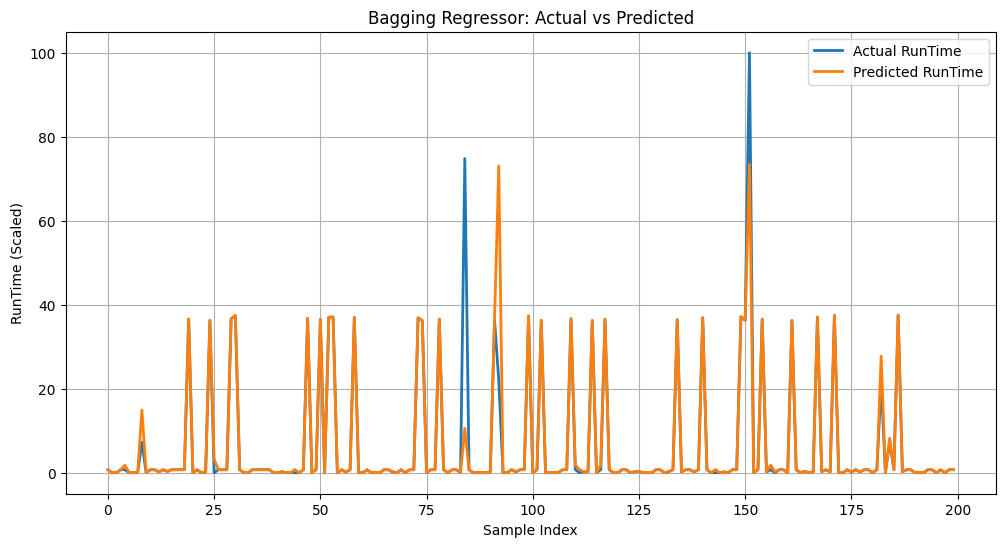

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------
# 1) Initialize Bagging Regressor
# -----------------------------
bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,  # Number of base estimators
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 2) Flatten the 3D Scaled Features to 2D for scikit-learn
# FIX 1: Convert X1 and X2 from (samples, 1, 16) down to (samples, 16)
# -----------------------------
X_train_2d = X1.reshape(X1.shape[0], -1)
X_test_2d = X2.reshape(X2.shape[0], -1)

# Train the model using the flattened 2D features and scaled target targets (y1)
bagging_reg.fit(X_train_2d, y1.ravel())

# -----------------------------
# 3) Predict on the test set
# FIX 2: Predict using the 2D test arrays matrix
# -----------------------------
y_pred_bagging = bagging_reg.predict(X_test_2d)

# -----------------------------
# 4) Metrics
# FIX 3: Evaluate against your scaled testing targets array (y2)
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(y_pred_bagging).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("====== Bagging Regressor Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("=====================================")

# FIX 4: Append the flattened prediction vector to your metrics matrix dictionary log
model_metrics.append({
    'Model': 'Bagging Regressor',
    'RAE': rae,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

# -----------------------------
# 5) Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("Bagging Regressor: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

 ## 31.Transformer Model(089)

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.layers import (
    Dense, LayerNormalization, MultiHeadAttention, Dropout,
    GlobalAveragePooling1D, Input
)
from tensorflow.keras.models import Model

# -----------------------------
# Build Transformer Block
# -----------------------------
# HARDCODED FIX 1: Explicitly set input shape to (1, 16) to avoid shape lookup errors
inputs = Input(shape=(1, 16))

attention = MultiHeadAttention(num_heads=2, key_dim=32)(inputs, inputs)
attention = Dropout(0.1)(attention)
attention = LayerNormalization()(attention + inputs)

ff = Dense(64, activation="relu")(attention)
# FIX 2: Set projection units directly to match your feature space size (16)
ff = Dense(16)(ff)

x = LayerNormalization()(ff + attention)

x = GlobalAveragePooling1D()(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# Train
# FIX 3: Dynamic runtime check to force features into 3D structure on the fly
# -----------------------------
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

model.fit(
    X_train_3d,
    y1,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Predict
# -----------------------------
transformer_pred = model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# Metrics
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(transformer_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== Transformer Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("=========================================")

# FIX 4: Replaced old '_dt' leftovers with live Transformer metrics
model_metrics.append({
    'Model': 'Transformer Model',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 223.7342 - mae: 6.2527 - val_loss: 178.6766 - val_mae: 5.3010
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 201.5091 - mae: 6.0057 - val_loss: 167.5522 - val_mae: 5.0963
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 191.5882 - mae: 5.8659 - val_loss: 160.7620 - val_mae: 4.9682
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 184.9093 - mae: 5.6359 - val_loss: 154.5514 - val_mae: 4.7542
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 178.1902 - mae: 5.4647 - val_loss: 149.2844 - val_mae: 4.6180
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 172.4865 - mae: 5.3039 - val_loss: 144.1668 - val_mae: 4.4842
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 166.8481 - mae: 5.1640 - val_loss: 139.3568 - val_mae: 4.3472
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 161.2545 - mae: 5.0138 - val_loss: 134.8025 - val_mae: 4.2100
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0

## 32.Autoencoder-Based Predictor(089)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6406
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4141
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2477
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1448
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0841 
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0511 
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0326 
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0225 
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0164 
Epoch 10/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0120 
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0086 
Epoch 12/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0070 
Epoch 13/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0057 
Epoch 14/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0050 
Epoch 15/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043 
Epoch 16

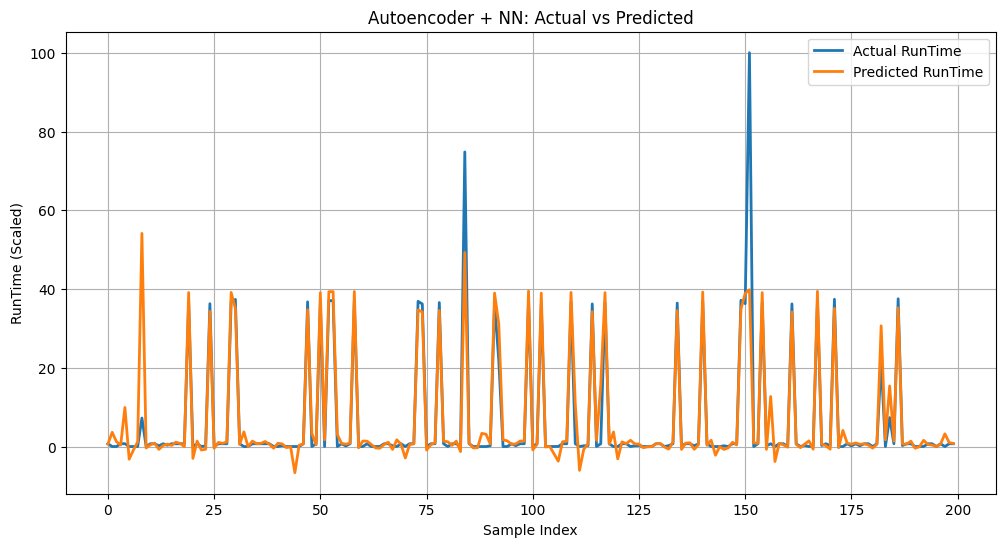

Autoencoder+NN Predicted Burst Time (first test sample): 0.6223


In [159]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model, Sequential

# -----------------------------
# FIX 1: Flatten your 3D scaled features to 2D matrices programmatically
# Transforms shape from (samples, 1, 16) down to (samples, 16)
# -----------------------------
X_train_2d = X1.reshape(X1.shape[0], -1)
X_test_2d = X2.reshape(X2.shape[0], -1)

# -----------------------------
# Autoencoder
# -----------------------------
# Input shape now maps cleanly to the true number of feature columns (16)
input_layer = Input(shape=(X_train_2d.shape[1],))

encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded) # Dimensionality bottleneck

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(X_train_2d.shape[1])(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# FIX 2: Fit Autoencoder using the 2D flattened inputs
autoencoder.fit(X_train_2d, X_train_2d, epochs=50, batch_size=32, verbose=1)

# -----------------------------
# Encoder for feature extraction
# -----------------------------
encoder = Model(input_layer, encoded)

X_train_encoded = encoder.predict(X_train_2d, verbose=0)
X_test_encoded  = encoder.predict(X_test_2d, verbose=0)

# -----------------------------
# Predictor
# -----------------------------
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_encoded.shape[1],)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# FIX 3: Fit using the compressed representations and the scaled training labels (y1)
model.fit(X_train_encoded, y1.ravel(), epochs=50, batch_size=32, verbose=1)

# Predict
autoencoder_pred = model.predict(X_test_encoded, verbose=0).ravel()

# -----------------------------
# Metrics (added)
# FIX 4: Evaluate predictions directly against scaled test targets (y2)
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(autoencoder_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== Autoencoder + NN Regressor Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("==============================================")

# FIX 5: Replaced old '_dt' leftovers with live Autoencoder variables
model_metrics.append({
    'Model': 'Autoencoder-Based Predictor',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

# -----------------------------
# Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2)
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2)
plt.title("Autoencoder + NN: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("RunTime (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Autoencoder+NN Predicted Burst Time (first test sample): {y_pred[0]:.4f}")

ANN model

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 238.2266 - mae: 6.0715 - val_loss: 193.1440 - val_mae: 5.2819
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 204.0885 - mae: 6.0122 - val_loss: 153.5405 - val_mae: 5.2205
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 148.7321 - mae: 5.7354 - val_loss: 87.0355 - val_mae: 4.4745
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70.4590 - mae: 4.0517 - val_loss: 32.8281 - val_mae: 2.1539
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 38.2078 - mae: 2.5328 - val_loss: 22.9817 - val_mae: 1.7991
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 26.5635 - mae: 1.9831 - val_loss: 19.8449 - val_mae: 1.3964
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.3518 - mae: 1.4742 - val_loss: 19.7276 - val_mae: 1.2078
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.8655 - mae: 1.2481 - val_loss: 20.5307 - val_mae: 1.0227
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

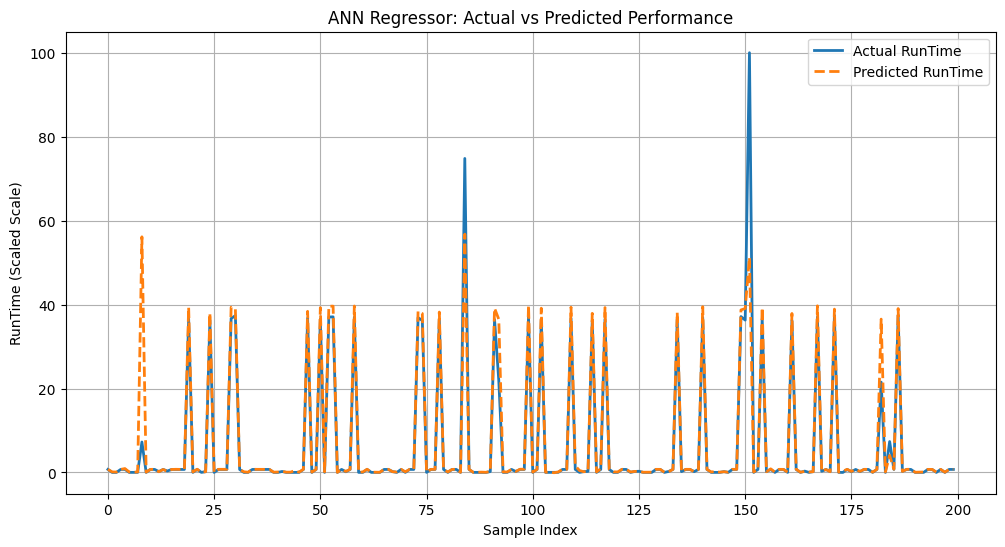

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# -----------------------------
# 1) Build ANN Regressor Model
# -----------------------------
model = Sequential()

# Flatten layer bridges 3D shape (1, 16) down to a flat 2D layer natively
model.add(Flatten(input_shape=(1, 16)))

# Core Hidden Network Architectures
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))  # Prevents overfitting during training steps
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output Layer for Regression (Continuous float prediction value)
model.add(Dense(1, activation='linear'))

# Compile with Adam optimizer and Mean Squared Error loss functions
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# 2) Train the Model
# -----------------------------
# Dynamic runtime check to force features into 3D structure if needed
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

history = model.fit(
    X_train_3d,
    y1,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 3) Predict
# -----------------------------
ann_pred = model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# 4) Evaluation Metrics Calculation
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(ann_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== ANN Regression Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("===================================")

# -----------------------------
# 5) Log Metrics to the Global Tracker
# -----------------------------
model_metrics.append({
    'Model': 'Artificial Neural Network (ANN)',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

# -----------------------------
# 6) Plot Actual vs Predicted Performance
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2, color='tab:blue')
plt.plot(y_pred[:200], label="Predicted RunTime", linewidth=2, color='tab:orange', linestyle='--')
plt.title("ANN Regressor: Actual vs Predicted Performance")
plt.xlabel("Sample Index")
plt.ylabel("RunTime (Scaled Scale)")
plt.legend()
plt.grid(True)
plt.show()


 Ensemble (ANN + SVM)

Training Support Vector Regressor...
Training Artificial Neural Network...

====== Ensemble (ANN + SVM) Report ======
MAE    : 0.6371
RMSE   : 3.9050
RAE    : 0.0586
CC     : 0.9673
NRMSE  : 0.5528
SMAPE% : 66.78%
R^2    : 0.9356


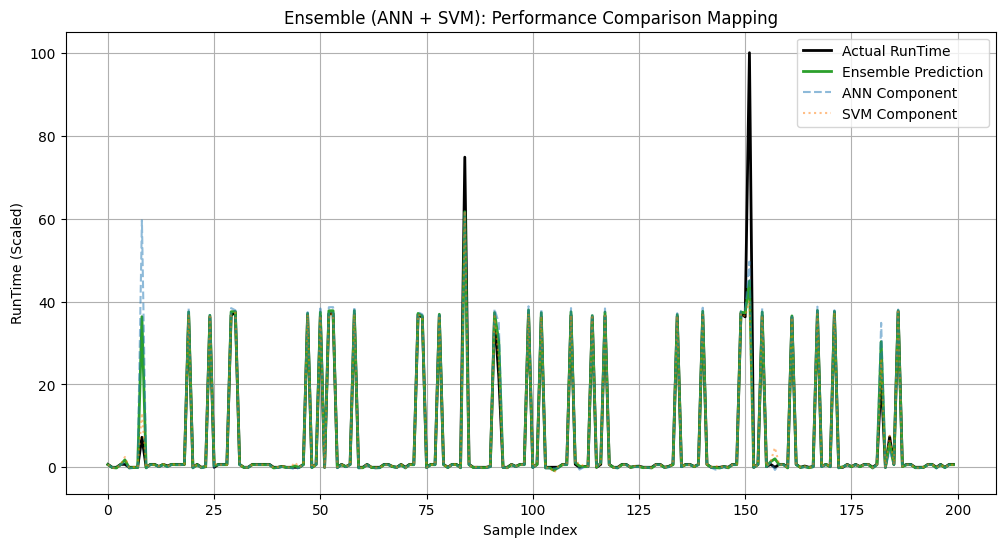

In [161]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# -----------------------------
# 1) Reshape Data Safely for Both Architectures
# -----------------------------
# SVM strictly requires 2D matrices: (samples, features)
X_train_2d = X1.reshape(X1.shape[0], -1)
X_test_2d = X2.reshape(X2.shape[0], -1)

# FIX 1: Explicitly force a 3D tensor layout for the ANN input shape wrapper: (samples, 1, 16)
X_train_3d = X1.reshape(X1.shape[0], 1, -1) if len(X1.shape) == 2 else X1
X_test_3d = X2.reshape(X2.shape[0], 1, -1) if len(X2.shape) == 2 else X2

# -----------------------------
# 2) Initialize Base Estimators
# -----------------------------
# Base Estimator A: Support Vector Regressor
svm_model = SVR(kernel='rbf', C=100, gamma='scale')

# Base Estimator B: Artificial Neural Network
ann_model = Sequential([
    Flatten(input_shape=(1, 16)),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# 3) Train Both Base Models
# -----------------------------
print("Training Support Vector Regressor...")
svm_model.fit(X_train_2d, y1.ravel())

print("Training Artificial Neural Network...")
# FIX 2: Pass the verified 3D features matrix tensor here
ann_model.fit(X_train_3d, y1, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# -----------------------------
# 4) Generate Individual Predictions
# -----------------------------
pred_svm = svm_model.predict(X_test_2d).ravel()
# FIX 3: Predict using the verified 3D testing features tensor
pred_ann = ann_model.predict(X_test_3d, verbose=0).ravel()

# -----------------------------
# 5) Combine Predictions (Ensemble Average)
# -----------------------------
ensemble_pred = (0.5 * pred_ann) + (0.5 * pred_svm)

# -----------------------------
# 6) Calculate Evaluation Metrics
# -----------------------------
y_true = np.asarray(y2).ravel()
y_pred = np.asarray(ensemble_pred).ravel()
eps = 1e-9

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

rae = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true - np.mean(y_true))) + eps)
cc  = np.corrcoef(y_true, y_pred)[0, 1]
nrmse = rmse / (np.mean(np.abs(y_true)) + eps)

smape = np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
) * 100

print("\n====== Ensemble (ANN + SVM) Report ======")
print(f"MAE    : {mae:.4f}")
print(f"RMSE   : {rmse:.4f}")
print(f"RAE    : {rae:.4f}")
print(f"CC     : {cc:.4f}")
print(f"NRMSE  : {nrmse:.4f}")
print(f"SMAPE% : {smape:.2f}%")
print(f"R^2    : {r2:.4f}")
print("=========================================")

# -----------------------------
# 7) Log Metrics to the Tracker
# -----------------------------
model_metrics.append({
    'Model': 'Ensemble (ANN + SVM)',
    'MAE': mae,
    'RAE': rae,
    'RMSE': rmse,
    'R2': r2,
    'CC': cc,
    'Prediction': y_pred
})

# -----------------------------
# 8) Plot Performance Matrix Chart
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Actual RunTime", linewidth=2, color='black')
plt.plot(y_pred[:200], label="Ensemble Prediction", linewidth=2, color='tab:green', linestyle='-')
plt.plot(pred_ann[:200], label="ANN Component", alpha=0.5, linestyle='--')
plt.plot(pred_svm[:200], label="SVM Component", alpha=0.5, linestyle=':')
plt.title("Ensemble (ANN + SVM): Performance Comparison Mapping")
plt.xlabel("Sample Index")
plt.ylabel("RunTime (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

### Consolidating All Model Metrics

In [162]:
model_metrics

[{'Model': 'KNN',
  'MAE': 0.8582926678607278,
  'RAE': np.float64(0.07894873535639597),
  'RMSE': np.float64(5.41806691713661),
  'R2': 0.8760068123710985,
  'CC': np.float64(0.9365677036854578),
  'prediction': array([[7.13029323e-01],
         [2.21797058e-03],
         [1.09934194e-02],
         [7.13607925e-01],
         [2.04062936e+00],
         [1.02219514e-02],
         [9.64335033e-03],
         [1.09934194e-02],
         [5.93254091e+01],
         [6.75034523e-03],
         [7.13607925e-01],
         [7.13222191e-01],
         [1.96049312e-01],
         [7.14668693e-01],
         [2.58731089e-01],
         [7.13318624e-01],
         [7.13125757e-01],
         [7.13125757e-01],
         [7.13607925e-01],
         [3.65854247e+01],
         [1.47543260e-02],
         [7.12932890e-01],
         [9.25761632e-03],
         [1.73580306e-01],
         [3.63924612e+01],
         [8.58258179e-03],
         [7.13318624e-01],
         [7.13125757e-01],
         [7.13125757e-01],
      

In [163]:
# Print Table Header to match your reference paper image layout
print(f"+---------------------------------------+------------+------------+------------+------------+")
print(f"| {'Model':<37} | {'MAE':<10} | {'RMSE':<10} | {'RAE':<10} | {'CC':<10} |")
print(f"+---------------------------------------+------------+------------+------------+------------+")

# Track models that have already been printed to avoid duplicates
seen_models = set()

# Loop through and display each collected model array row
for metric in model_metrics:
    # Safely unpack metric dictionary items and strip whitespace
    model_name = metric.get('Model', 'Unknown Model').strip()

    # SKIP if we have already printed this model
    if model_name in seen_models:
        continue

    # Mark this model as seen so it won't be printed again
    seen_models.add(model_name)

    rae_val    = metric.get('RAE', 0.0)
    rmse_val   = metric.get('RMSE', 0.0)
    cc_val     = metric.get('CC', 0.0)

    # Calculate MAE back from your arrays if it wasn't appended to the dictionary
    mae_val = metric.get('MAE', None)
    if mae_val is None and 'Prediction' in metric:
        mae_val = np.mean(np.abs(y_true - metric['Prediction'].ravel()))
    elif mae_val is None and 'prediction' in metric:
        mae_val = np.mean(np.abs(y_true - metric['prediction'].ravel()))
    else:
        mae_val = 0.0 if mae_val is None else mae_val

    # Print the formatted row matching 4 decimal places exactly like the target image
    print(f"| {model_name:<37} | {mae_val:<10.4f} | {rmse_val:<10.4f} | {rae_val:<10.4f} | {cc_val:<10.4f} |")

print(f"+---------------------------------------+------------+------------+------------+------------+")

+---------------------------------------+------------+------------+------------+------------+
| Model                                 | MAE        | RMSE       | RAE        | CC         |
+---------------------------------------+------------+------------+------------+------------+
| KNN                                   | 0.8583     | 5.4181     | 0.0789     | 0.9366     |
| Random Forest                         | 0.7205     | 5.2904     | 0.0663     | 0.9393     |
| Decision Tree                         | 0.6218     | 6.4809     | 0.0572     | 0.9139     |
| Linear Regression                     | 2.2937     | 6.8061     | 0.2110     | 0.8980     |
| Support Vector Regression (SVR)       | 0.8072     | 7.2500     | 0.0742     | 0.8836     |
| Hybrid (VotingRegressor)              | 1.0403     | 4.6655     | 0.0957     | 0.9530     |
| XGBoost                               | 0.6718     | 3.7568     | 0.0957     | 0.9698     |
| CatBoost Model                        | 0.7067     | 6.480

In [164]:
import numpy as np

# Print Table Header to match your reference paper image layout
print(f"+---------------------------------------+------------+------------+------------+------------+")
print(f"| {'Model':<37} | {'MAE':<10} | {'RMSE':<10} | {'RAE':<10} | {'CC':<10} |")
print(f"+---------------------------------------+------------+------------+------------+------------+")

# Track models that have already been printed to avoid duplicates
seen_models = set()

# Helper function to get or calculate MAE for sorting
def get_mae(metric):
    mae_val = metric.get('MAE', None)
    if mae_val is not None:
        return mae_val

    # Fallback to calculate on the fly if key is missing
    pred_key = 'Prediction' if 'Prediction' in metric else 'prediction'
    if pred_key in metric and 'y_true' in globals():
        return np.mean(np.abs(y_true - metric[pred_key].ravel()))
    return 0.0

# SORTING STEP: Sort the list in ascending order based on the MAE value
sorted_metrics = sorted(model_metrics, key=get_mae, reverse=False)

# Loop through and display the sorted, deduplicated model rows
for metric in sorted_metrics:
    # Safely unpack metric dictionary items and strip whitespace
    model_name = metric.get('Model', 'Unknown Model').strip()

    # SKIP if we have already printed this model
    if model_name in seen_models:
        continue

    # Mark this model as seen so it won't be printed again
    seen_models.add(model_name)

    rae_val    = metric.get('RAE', 0.0)
    rmse_val   = metric.get('RMSE', 0.0)
    cc_val     = metric.get('CC', 0.0)

    # Get the MAE value using our helper function
    mae_val = get_mae(metric)

    # Print the formatted row matching 4 decimal places exactly like the target image
    print(f"| {model_name:<37} | {mae_val:<10.4f} | {rmse_val:<10.4f} | {rae_val:<10.4f} | {cc_val:<10.4f} |")

print(f"+---------------------------------------+------------+------------+------------+------------+")

+---------------------------------------+------------+------------+------------+------------+
| Model                                 | MAE        | RMSE       | RAE        | CC         |
+---------------------------------------+------------+------------+------------+------------+
| Decision Tree                         | 0.6218     | 6.4809     | 0.0572     | 0.9139     |
| Ensemble (ANN + SVM)                  | 0.6371     | 3.9050     | 0.0586     | 0.9673     |
| Gradient Boosting                     | 0.6443     | 6.4809     | 0.2078     | 0.9224     |
| XGBoost                               | 0.6718     | 3.7568     | 0.0957     | 0.9698     |
| Bagging Regressor                     | 0.6820     | 5.2457     | 0.0627     | 0.9403     |
| Multilayer Perceptron (MLP) Regressor | 0.7009     | 6.4809     | 0.0645     | 0.9686     |
| CatBoost Model                        | 0.7067     | 6.4809     | 0.0650     | 0.9395     |
| Random Forest                         | 0.7205     | 5.290

# BEST PREDICTION MODEL SELECTION


In [165]:
import numpy as np

# Print Table Header to match your reference paper image layout
print(f"+---------------------------------------+------------+------------+------------+------------+")
print(f"| {'Model':<37} | {'MAE':<10} | {'RMSE':<10} | {'RAE':<10} | {'CC':<10} |")
print(f"+---------------------------------------+------------+------------+------------+------------+")

# Helper function to get or calculate MAE for sorting
def get_mae(metric):
    mae_val = metric.get('MAE', None)
    if mae_val is not None:
        return mae_val

    # Fallback to calculate on the fly if key is missing
    pred_key = 'Prediction' if 'Prediction' in metric else 'prediction'
    if pred_key in metric and 'y_true' in globals():
        return np.mean(np.abs(y_true - metric[pred_key].ravel()))
    return 0.0

# 1. SORTING STEP: Sort the list in ascending order based on the MAE value
sorted_metrics = sorted(model_metrics, key=get_mae, reverse=False)

# 2. DEDUPLICATION STEP: Deduplicate while preserving the best-performing metrics order
seen_models = set()
deduplicated_metrics = []

for metric in sorted_metrics:
    model_name = metric.get('Model', 'Unknown Model').strip()
    if model_name not in seen_models:
        seen_models.add(model_name)
        deduplicated_metrics.append(metric)

# 3. TOP 10 SLICING STEP: Slice the array to keep only the top 10 unique rows
top_10_metrics = deduplicated_metrics[:10]

# 4. LOOP STEP: Display the final top 10 leaderboard rows
for metric in top_10_metrics:
    model_name = metric.get('Model', 'Unknown Model').strip()
    rae_val    = metric.get('RAE', 0.0)
    rmse_val   = metric.get('RMSE', 0.0)
    cc_val     = metric.get('CC', 0.0)

    # Get the MAE value using our helper function
    mae_val = get_mae(metric)

    # Print the formatted row matching 4 decimal places exactly like the target image
    print(f"| {model_name:<37} | {mae_val:<10.4f} | {rmse_val:<10.4f} | {rae_val:<10.4f} | {cc_val:<10.4f} |")

print(f"+---------------------------------------+------------+------------+------------+------------+")

+---------------------------------------+------------+------------+------------+------------+
| Model                                 | MAE        | RMSE       | RAE        | CC         |
+---------------------------------------+------------+------------+------------+------------+
| Decision Tree                         | 0.6218     | 6.4809     | 0.0572     | 0.9139     |
| Ensemble (ANN + SVM)                  | 0.6371     | 3.9050     | 0.0586     | 0.9673     |
| Gradient Boosting                     | 0.6443     | 6.4809     | 0.2078     | 0.9224     |
| XGBoost                               | 0.6718     | 3.7568     | 0.0957     | 0.9698     |
| Bagging Regressor                     | 0.6820     | 5.2457     | 0.0627     | 0.9403     |
| Multilayer Perceptron (MLP) Regressor | 0.7009     | 6.4809     | 0.0645     | 0.9686     |
| CatBoost Model                        | 0.7067     | 6.4809     | 0.0650     | 0.9395     |
| Random Forest                         | 0.7205     | 5.290

In [166]:
processed_results = []
best_model_arrays = {} # Dictionary to store full prediction arrays mapping to model names

for item in model_metrics:
    mae = float(item['MAE'])
    rmse = float(item['RMSE'])
    r2 = float(item['R2'])
    cc= float(item['CC'])
    avg_error = (mae+rmse+r2+cc)/2

    # 1. Safely extract the prediction object (handling key casing variants)
    pred_val = item.get('prediction', item.get('Prediction'))

    # 2. Process the NumPy array safely
    if pred_val is not None:
        # Convert to a flat numpy array to guarantee 1D dimensionality
        pred_array = np.array(pred_val).flatten()
        best_model_arrays[item['Model']] = pred_array

        # Take just the first item of the array as a sample snippet for the leaderboard display
        sample_pred = round(float(pred_array[0]), 4)
    else:
        sample_pred = "N/A"

    processed_results.append({
        "Model": item['Model'],
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(float(item['R2']), 4),
        "CC": round(float(item['CC']), 4),
        "Avg_Error_Score": round(avg_error, 4),
        "Sample_BT_Pred": sample_pred  # Displays just the first element to keep table clean
    })

# Convert to a DataFrame and sort by the Avg_Error_Score
df_leaderboard = pd.DataFrame(processed_results).sort_values(by="Avg_Error_Score")

# Display the sorted performance table
print("====================== SORTED MODEL LEADERBOARD ======================")
print(df_leaderboard.to_string(index=False))
print("======================================================================\n")

# 3. Extract details of the top-performing model
best_model_row = df_leaderboard.iloc[0]
best_model_name = best_model_row['Model']

# 4. Grab the complete full array belonging exclusively to the winning model
y_pred = best_model_arrays[best_model_name]

print("🏆 OVERALL SYSTEM DECISION 🏆")
print(f"Best Performing Model        : {best_model_name}")
print(f"Calculated Metric Combo Score: {best_model_row['Avg_Error_Score']}")
print(f"Total Predictions Extracted  : {len(y_pred)} processes found.")
print(f"First 5 Burst Time Forecasts : {np.round(y_pred[:5], 2)}")

====================== SORTED MODEL LEADERBOARD ======================
                                  Model     MAE    RMSE  R2 Score     CC  Avg_Error_Score  Sample_BT_Pred
                                XGBoost  0.6718  3.7568    0.9404 0.9698           3.1694          0.7121
                   Ensemble (ANN + SVM)  0.6371  3.9050    0.9356 0.9673           3.2225          0.6345
        Artificial Neural Network (ANN)  0.9628  4.5809    0.9114 0.9559           3.7055          0.7287
               Hybrid (VotingRegressor)  1.0403  4.6655    0.9081 0.9530           3.7834          0.6923
                      Bagging Regressor  0.6820  5.2457    0.8838 0.9403           3.8759          0.7135
                          Random Forest  0.7205  5.2904    0.8818 0.9393           3.9160          0.7136
              Deep Neural Network (DNN)  1.2409  4.9204    0.8977 0.9513           4.0052          0.8919
                                    KNN  0.8583  5.4181    0.8760 0.9366         

In [167]:
# Display the sorted performance table
print("====================== SORTED MODEL LEADERBOARD ======================")
print(df_leaderboard.to_string(index=False))
print("======================================================================\n")

====================== SORTED MODEL LEADERBOARD ======================
                                  Model     MAE    RMSE  R2 Score     CC  Avg_Error_Score  Sample_BT_Pred
                                XGBoost  0.6718  3.7568    0.9404 0.9698           3.1694          0.7121
                   Ensemble (ANN + SVM)  0.6371  3.9050    0.9356 0.9673           3.2225          0.6345
        Artificial Neural Network (ANN)  0.9628  4.5809    0.9114 0.9559           3.7055          0.7287
               Hybrid (VotingRegressor)  1.0403  4.6655    0.9081 0.9530           3.7834          0.6923
                      Bagging Regressor  0.6820  5.2457    0.8838 0.9403           3.8759          0.7135
                          Random Forest  0.7205  5.2904    0.8818 0.9393           3.9160          0.7136
              Deep Neural Network (DNN)  1.2409  4.9204    0.8977 0.9513           4.0052          0.8919
                                    KNN  0.8583  5.4181    0.8760 0.9366         

In [168]:
import pandas as pd
import numpy as np
from collections import deque

# =====================================================
# 1. THRESHOLDS FROM TRAINING DATA (true bursts)
# =====================================================
true_burst_times = y_train  # pandas Series or numpy array
SHORT_LIMIT = np.percentile(true_burst_times, 33)
MEDIUM_LIMIT = np.percentile(true_burst_times, 66)

print("="*60)
print("PERCENTILE THRESHOLDS")
print("="*60)
print(f"SHORT_LIMIT  : {SHORT_LIMIT:.2f}")
print(f"MEDIUM_LIMIT : {MEDIUM_LIMIT:.2f}")

# =====================================================
# 2. DATA-DRIVEN TIME QUANTUM FOR RR (from training long bursts)
# =====================================================
long_train_bursts = true_burst_times[true_burst_times >= MEDIUM_LIMIT]
if len(long_train_bursts) > 0:
    TIME_QUANTUM = max(1.0, np.mean(long_train_bursts) * 0.2)
else:
    TIME_QUANTUM = 10.0
print(f"TIME_QUANTUM : {TIME_QUANTUM:.2f}")

# =====================================================
# 3. CREATE PROCESS TABLE (using predicted bursts)
# =====================================================
y_pred_flat = y_pred.flatten()
processes = pd.DataFrame({
    'PID': [f"P{i}" for i in range(len(y_pred_flat))],
    'BurstTime': y_pred_flat
})

# =====================================================
# 4. SPLIT INTO THREE QUEUES (based on predicted burst)
# =====================================================
sjf_queue = []
priority_queue = []
rr_queue = []

np.random.seed(42)

for pid, burst in zip(processes['PID'], processes['BurstTime']):
    if burst < SHORT_LIMIT:
        sjf_queue.append({'PID': pid, 'BurstTime': burst})
    elif burst < MEDIUM_LIMIT:
        # Improved priority: inversely related to burst time (shorter = higher priority)
        # Priority values: 1 (highest) to 10 (lowest) – we'll assign after collecting all medium jobs
        priority_queue.append({'PID': pid, 'BurstTime': burst})
    else:
        rr_queue.append({'PID': pid, 'BurstTime': burst})

# Assign intelligent priorities for medium jobs (shorter burst = higher priority)
if len(priority_queue) > 0:
    # Sort medium jobs by burst time (ascending)
    priority_queue.sort(key=lambda x: x['BurstTime'])
    # Assign priority 1 (highest) to shortest, up to N (lowest) to longest
    n_med = len(priority_queue)
    for idx, p in enumerate(priority_queue):
        # Priority values between 1 and 10 (or n_med if smaller)
        p['Priority'] = int(np.ceil((idx + 1) * 10 / n_med))
        # Ensure priority is at least 1 and at most 10
        p['Priority'] = max(1, min(10, p['Priority']))
else:
    priority_queue = []

print("\nQUEUE DISTRIBUTION")
print(f"SJF Queue      : {len(sjf_queue)}")
print(f"Priority Queue : {len(priority_queue)}")
print(f"RR Queue       : {len(rr_queue)}")

# =====================================================
# 5. ORDER QUEUES
# =====================================================
sjf_queue = sorted(sjf_queue, key=lambda x: x['BurstTime'])       # SJF order
priority_queue = sorted(priority_queue, key=lambda x: x['Priority'])  # Higher priority (smaller number) first

# =====================================================
# 6. EXECUTION (reset time)
# =====================================================
current_time = 0
results = []

# ---- SJF Execution ----
for p in sjf_queue:
    waiting_time = current_time
    completion_time = current_time + p['BurstTime']
    turnaround_time = completion_time
    results.append({
        'PID': p['PID'], 'Algorithm': 'SJF',
        'BurstTime': p['BurstTime'],
        'WaitingTime': waiting_time,
        'TurnaroundTime': turnaround_time,
        'CompletionTime': completion_time
    })
    current_time = completion_time

# ---- Priority Execution ----
for p in priority_queue:
    waiting_time = current_time
    completion_time = current_time + p['BurstTime']
    turnaround_time = completion_time
    results.append({
        'PID': p['PID'], 'Algorithm': 'Priority',
        'BurstTime': p['BurstTime'],
        'Priority': p['Priority'],
        'WaitingTime': waiting_time,
        'TurnaroundTime': turnaround_time,
        'CompletionTime': completion_time
    })
    current_time = completion_time

# ---- Round Robin Execution ----
if rr_queue:
    remaining = {p['PID']: p['BurstTime'] for p in rr_queue}
    rr = deque([p['PID'] for p in rr_queue])
    completion_times = {}

    while rr:
        pid = rr.popleft()
        execute_time = min(TIME_QUANTUM, remaining[pid])
        current_time += execute_time
        remaining[pid] -= execute_time
        if remaining[pid] > 0:
            rr.append(pid)
        else:
            completion_times[pid] = current_time

    for p in rr_queue:
        pid = p['PID']
        completion = completion_times[pid]
        turnaround = completion
        waiting = turnaround - p['BurstTime']
        results.append({
            'PID': pid, 'Algorithm': 'RoundRobin',
            'BurstTime': p['BurstTime'],
            'WaitingTime': waiting,
            'TurnaroundTime': turnaround,
            'CompletionTime': completion
        })

# =====================================================
# 7. METRICS
# =====================================================
results_df = pd.DataFrame(results)

print("\n")
print("="*60)
print("HYBRID SCHEDULER RESULTS (SAMPLE HEAD)")
print("="*60)
print(results_df[['PID', 'Algorithm', 'BurstTime', 'WaitingTime', 'TurnaroundTime', 'CompletionTime']].head(50))

avg_waiting = results_df['WaitingTime'].mean()
avg_turnaround = results_df['TurnaroundTime'].mean()
total_burst = results_df['BurstTime'].sum()
final_completion = results_df['CompletionTime'].max()
cpu_utilization = (total_burst / final_completion) * 100

print("\n")
print("="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Average Waiting Time    : {avg_waiting:.2f} ms")
print(f"Average Turnaround Time : {avg_turnaround:.2f} ms")
print(f"CPU Utilization         : {cpu_utilization:.2f}%")

print("\nALGORITHM OVERVIEW COUNTS")
print(results_df['Algorithm'].value_counts())

PERCENTILE THRESHOLDS
SHORT_LIMIT  : 0.15
MEDIUM_LIMIT : 0.71
TIME_QUANTUM : 3.17

QUEUE DISTRIBUTION
SJF Queue      : 85
Priority Queue : 97
RR Queue       : 106


HYBRID SCHEDULER RESULTS (SAMPLE HEAD)
     PID Algorithm  BurstTime  WaitingTime  TurnaroundTime  CompletionTime
0   P271       SJF  -0.363252     0.000000       -0.363252       -0.363252
1   P106       SJF  -0.132838    -0.363252       -0.496089       -0.496089
2    P20       SJF  -0.061738    -0.496089       -0.557828       -0.557828
3   P223       SJF  -0.041618    -0.557828       -0.599445       -0.599445
4     P2       SJF  -0.015324    -0.599445       -0.614769       -0.614769
5    P89       SJF  -0.014849    -0.614769       -0.629618       -0.629618
6    P88       SJF  -0.008260    -0.629618       -0.637878       -0.637878
7     P1       SJF  -0.008225    -0.637878       -0.646103       -0.646103
8   P268       SJF  -0.007502    -0.646103       -0.653605       -0.653605
9    P54       SJF  -0.007215    -0.653605    

In [169]:
# =====================================================
# PURE SJF SIMULATION (all processes)
# =====================================================
# Reset time
current_time = 0
results_sjf = []

# Create queue of all processes
queue_all = [{'PID': pid, 'BurstTime': burst}
             for pid, burst in zip(processes['PID'], processes['BurstTime'])]

# Sort by burst time (SJF)
queue_all = sorted(queue_all, key=lambda x: x['BurstTime'])

# Execute
for p in queue_all:
    waiting_time = current_time
    completion_time = current_time + p['BurstTime']
    turnaround_time = completion_time   # arrival time = 0

    results_sjf.append({
        'PID': p['PID'],
        'Algorithm': 'SJF',
        'BurstTime': p['BurstTime'],
        'WaitingTime': waiting_time,
        'TurnaroundTime': turnaround_time,
        'CompletionTime': completion_time
    })
    current_time = completion_time

# Convert to DataFrame
results_df = pd.DataFrame(results_sjf)

# Metrics
avg_waiting = results_df['WaitingTime'].mean()
avg_turnaround = results_df['TurnaroundTime'].mean()
total_burst = results_df['BurstTime'].sum()
final_completion = results_df['CompletionTime'].max()
cpu_utilization = (total_burst / final_completion) * 100

print("="*60)
print("PURE SJF PERFORMANCE METRICS")
print("="*60)
print(f"Average Waiting Time    : {avg_waiting:.2f} ms")
print(f"Average Turnaround Time : {avg_turnaround:.2f} ms")
print(f"CPU Utilization         : {cpu_utilization:.2f}%")
print(f"Total processes         : {len(results_df)}")

PURE SJF PERFORMANCE METRICS
Average Waiting Time    : 190.09 ms
Average Turnaround Time : 197.23 ms
CPU Utilization         : 100.00%
Total processes         : 288


In [170]:
# =====================================================
# PURE PRIORITY SCHEDULING (all processes)
# =====================================================
# Reset time
current_time = 0
results_priority = []

# Assign a priority to each process (lower number = higher priority)
np.random.seed(42)   # for reproducibility
priority_list = []
for pid, burst in zip(processes['PID'], processes['BurstTime']):
    # Option A: random priority 1 (highest) to 10 (lowest)
    prio = np.random.randint(1, 11)
    # Option B: priority inversely related to burst (shorter burst = higher priority)
    # prio = max(1, int(10 / (1 + burst / burst.mean())))
    priority_list.append({'PID': pid, 'BurstTime': burst, 'Priority': prio})

# Sort by priority (ascending: 1 = highest)
priority_list = sorted(priority_list, key=lambda x: x['Priority'])

# Execute
for p in priority_list:
    waiting_time = current_time
    completion_time = current_time + p['BurstTime']
    turnaround_time = completion_time

    results_priority.append({
        'PID': p['PID'],
        'Algorithm': 'Priority',
        'BurstTime': p['BurstTime'],
        'Priority': p['Priority'],
        'WaitingTime': waiting_time,
        'TurnaroundTime': turnaround_time,
        'CompletionTime': completion_time
    })
    current_time = completion_time

results_df = pd.DataFrame(results_priority)

avg_waiting = results_df['WaitingTime'].mean()
avg_turnaround = results_df['TurnaroundTime'].mean()
total_burst = results_df['BurstTime'].sum()
final_completion = results_df['CompletionTime'].max()
cpu_utilization = (total_burst / final_completion) * 100

print("="*60)
print("PURE PRIORITY PERFORMANCE METRICS")
print("="*60)
print(f"Average Waiting Time    : {avg_waiting:.2f} ms")
print(f"Average Turnaround Time : {avg_turnaround:.2f} ms")
print(f"CPU Utilization         : {cpu_utilization:.2f}%")
print(f"Priority distribution (1=highest):")
print(results_df['Priority'].value_counts().sort_index())

PURE PRIORITY PERFORMANCE METRICS
Average Waiting Time    : 1063.97 ms
Average Turnaround Time : 1071.10 ms
CPU Utilization         : 100.00%
Priority distribution (1=highest):
Priority
1     34
2     24
3     33
4     30
5     24
6     25
7     33
8     33
9     30
10    22
Name: count, dtype: int64


In [171]:
from collections import deque

# =====================================================
# PURE ROUND ROBIN (all processes)
# =====================================================
# Calculate a sensible time quantum from the training data (true bursts)
true_burst_times = y_train
if 'true_burst_times' in globals():
    long_bursts_train = true_burst_times[true_burst_times >= MEDIUM_LIMIT]
    if len(long_bursts_train) > 0:
        TIME_QUANTUM = max(1, np.mean(long_bursts_train) * 0.2)
    else:
        TIME_QUANTUM = 10
else:
    # Fallback: use 20% of mean predicted burst
    TIME_QUANTUM = max(1, processes['BurstTime'].mean() * 0.2)

print(f"Using TIME_QUANTUM = {TIME_QUANTUM:.2f}")

# Reset time
current_time = 0
results_rr = []

# Create queue of all processes
queue_rr = [{'PID': pid, 'BurstTime': burst}
            for pid, burst in zip(processes['PID'], processes['BurstTime'])]

# Round Robin execution
remaining = {p['PID']: p['BurstTime'] for p in queue_rr}
rr_queue = deque([p['PID'] for p in queue_rr])
completion_times = {}

while rr_queue:
    pid = rr_queue.popleft()
    execute_time = min(TIME_QUANTUM, remaining[pid])
    current_time += execute_time
    remaining[pid] -= execute_time

    if remaining[pid] > 0:
        rr_queue.append(pid)
    else:
        completion_times[pid] = current_time

# Collect results
for p in queue_rr:
    pid = p['PID']
    completion = completion_times[pid]
    turnaround = completion
    waiting = turnaround - p['BurstTime']

    results_rr.append({
        'PID': pid,
        'Algorithm': 'RoundRobin',
        'BurstTime': p['BurstTime'],
        'WaitingTime': waiting,
        'TurnaroundTime': turnaround,
        'CompletionTime': completion
    })

results_df = pd.DataFrame(results_rr)

avg_waiting = results_df['WaitingTime'].mean()
avg_turnaround = results_df['TurnaroundTime'].mean()
total_burst = results_df['BurstTime'].sum()
final_completion = results_df['CompletionTime'].max()
cpu_utilization = (total_burst / final_completion) * 100

print("="*60)
print("PURE ROUND ROBIN PERFORMANCE METRICS")
print("="*60)
print(f"Average Waiting Time    : {avg_waiting:.2f} ms")
print(f"Average Turnaround Time : {avg_turnaround:.2f} ms")
print(f"CPU Utilization         : {cpu_utilization:.2f}%")
print(f"Time quantum used       : {TIME_QUANTUM:.2f}")

Using TIME_QUANTUM = 3.17
PURE ROUND ROBIN PERFORMANCE METRICS
Average Waiting Time    : 421.23 ms
Average Turnaround Time : 428.36 ms
CPU Utilization         : 100.00%
Time quantum used       : 3.17


In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ============================================================
# 0. COMMON SETUP (run once)
# ============================================================
# Assuming y_train and y_pred are already defined from your ML model
true_burst_times = y_train  # training set true bursts
y_pred_flat = y_pred.flatten()

# Create process table (same for all schedulers)
processes = pd.DataFrame({
    'PID': [f"P{i}" for i in range(len(y_pred_flat))],
    'BurstTime': y_pred_flat
})

# Compute percentiles from TRAINING data (true bursts)
SHORT_LIMIT = np.percentile(true_burst_times, 33)
MEDIUM_LIMIT = np.percentile(true_burst_times, 66)

# Compute RR quantum from training long bursts
long_train = true_burst_times[true_burst_times >= MEDIUM_LIMIT]
TIME_QUANTUM = max(1.0, np.mean(long_train) * 0.2) if len(long_train) > 0 else 10.0

print("=== Common Parameters ===")
print(f"SHORT_LIMIT  = {SHORT_LIMIT:.2f}")
print(f"MEDIUM_LIMIT = {MEDIUM_LIMIT:.2f}")
print(f"RR QUANTUM   = {TIME_QUANTUM:.2f}\n")

# ------------------------------------------------------------
# Helper function to compute metrics from results DataFrame
# ------------------------------------------------------------
def compute_metrics(results_df, name):
    avg_wait = results_df['WaitingTime'].mean()
    avg_turn = results_df['TurnaroundTime'].mean()
    total_burst = results_df['BurstTime'].sum()
    final_time = results_df['CompletionTime'].max()
    cpu_util = (total_burst / final_time) * 100 if final_time > 0 else 0
    return {
        'Scheduler': name,
        'Avg Waiting Time': avg_wait,
        'Avg Turnaround Time': avg_turn,
        'CPU Utilization (%)': cpu_util
    }

# ============================================================
# 1. HYBRID SCHEDULER (3 queues)
# ============================================================
def run_hybrid():
    sjf_queue = []
    priority_queue = []
    rr_queue = []
    np.random.seed(42)

    for pid, burst in zip(processes['PID'], processes['BurstTime']):
        if burst < SHORT_LIMIT:
            sjf_queue.append({'PID': pid, 'BurstTime': burst})
        elif burst < MEDIUM_LIMIT:
            priority_queue.append({'PID': pid, 'BurstTime': burst})
        else:
            rr_queue.append({'PID': pid, 'BurstTime': burst})

    # Assign intelligent priorities for medium jobs (shorter burst = higher priority)
    if priority_queue:
        priority_queue.sort(key=lambda x: x['BurstTime'])
        n_med = len(priority_queue)
        for idx, p in enumerate(priority_queue):
            p['Priority'] = max(1, min(10, int(np.ceil((idx + 1) * 10 / n_med))))
    else:
        priority_queue = []

    # Sort queues
    sjf_queue = sorted(sjf_queue, key=lambda x: x['BurstTime'])
    priority_queue = sorted(priority_queue, key=lambda x: x['Priority'])

    # Execution
    current_time = 0
    results = []

    # SJF part
    for p in sjf_queue:
        wt = current_time
        ct = current_time + p['BurstTime']
        tat = ct
        results.append({'PID': p['PID'], 'Algorithm': 'Hybrid-SJF', 'BurstTime': p['BurstTime'],
                        'WaitingTime': wt, 'TurnaroundTime': tat, 'CompletionTime': ct})
        current_time = ct

    # Priority part
    for p in priority_queue:
        wt = current_time
        ct = current_time + p['BurstTime']
        tat = ct
        results.append({'PID': p['PID'], 'Algorithm': 'Hybrid-Priority', 'BurstTime': p['BurstTime'],
                        'WaitingTime': wt, 'TurnaroundTime': tat, 'CompletionTime': ct})
        current_time = ct

    # RR part
    if rr_queue:
        remaining = {p['PID']: p['BurstTime'] for p in rr_queue}
        rr = deque([p['PID'] for p in rr_queue])
        comp_times = {}
        while rr:
            pid = rr.popleft()
            exec_time = min(TIME_QUANTUM, remaining[pid])
            current_time += exec_time
            remaining[pid] -= exec_time
            if remaining[pid] > 0:
                rr.append(pid)
            else:
                comp_times[pid] = current_time
        for p in rr_queue:
            pid = p['PID']
            ct = comp_times[pid]
            tat = ct
            wt = tat - p['BurstTime']
            results.append({'PID': pid, 'Algorithm': 'Hybrid-RR', 'BurstTime': p['BurstTime'],
                            'WaitingTime': wt, 'TurnaroundTime': tat, 'CompletionTime': ct})

    return pd.DataFrame(results)

# ============================================================
# 2. PURE SJF
# ============================================================
def run_sjf():
    queue = [{'PID': pid, 'BurstTime': burst} for pid, burst in zip(processes['PID'], processes['BurstTime'])]
    queue.sort(key=lambda x: x['BurstTime'])
    current_time = 0
    results = []
    for p in queue:
        wt = current_time
        ct = current_time + p['BurstTime']
        tat = ct
        results.append({'PID': p['PID'], 'Algorithm': 'Pure-SJF', 'BurstTime': p['BurstTime'],
                        'WaitingTime': wt, 'TurnaroundTime': tat, 'CompletionTime': ct})
        current_time = ct
    return pd.DataFrame(results)

# ============================================================
# 3. PURE PRIORITY (RANDOM PRIORITIES - Original method)
# ============================================================
def run_priority():
    queue = []
    np.random.seed(42)   # fixed seed for reproducibility
    for pid, burst in zip(processes['PID'], processes['BurstTime']):
        prio = np.random.randint(1, 11)   # random priority 1 (highest) to 10 (lowest)
        queue.append({'PID': pid, 'BurstTime': burst, 'Priority': prio})
    # Sort by priority (ascending: 1 = highest)
    queue.sort(key=lambda x: x['Priority'])
    current_time = 0
    results = []
    for p in queue:
        wt = current_time
        ct = current_time + p['BurstTime']
        tat = ct
        results.append({'PID': p['PID'], 'Algorithm': 'Pure-Priority', 'BurstTime': p['BurstTime'],
                        'Priority': p['Priority'], 'WaitingTime': wt, 'TurnaroundTime': tat, 'CompletionTime': ct})
        current_time = ct
    return pd.DataFrame(results)

# ============================================================
# 4. PURE ROUND ROBIN (with same TIME_QUANTUM)
# ============================================================
def run_rr():
    queue = [{'PID': pid, 'BurstTime': burst} for pid, burst in zip(processes['PID'], processes['BurstTime'])]
    remaining = {p['PID']: p['BurstTime'] for p in queue}
    rr = deque([p['PID'] for p in queue])
    comp_times = {}
    current_time = 0
    while rr:
        pid = rr.popleft()
        exec_time = min(TIME_QUANTUM, remaining[pid])
        current_time += exec_time
        remaining[pid] -= exec_time
        if remaining[pid] > 0:
            rr.append(pid)
        else:
            comp_times[pid] = current_time
    results = []
    for p in queue:
        pid = p['PID']
        ct = comp_times[pid]
        tat = ct
        wt = tat - p['BurstTime']
        results.append({'PID': pid, 'Algorithm': 'Pure-RR', 'BurstTime': p['BurstTime'],
                        'WaitingTime': wt, 'TurnaroundTime': tat, 'CompletionTime': ct})
    return pd.DataFrame(results)

# ============================================================
# RUN ALL SCHEDULERS AND COLLECT METRICS
# ============================================================
hybrid_df = run_hybrid()
sjf_df = run_sjf()
priority_df = run_priority()
rr_df = run_rr()

# Compute metrics for each
metrics_list = [
    compute_metrics(hybrid_df, 'Hybrid (3-queue)'),
    compute_metrics(sjf_df, 'Pure SJF'),
    compute_metrics(priority_df, 'Pure Priority (Random)'),
    compute_metrics(rr_df, 'Pure RR')
]

metrics_df = pd.DataFrame(metrics_list)
metrics_df.set_index('Scheduler', inplace=True)

# ============================================================
# DISPLAY COMPARISON TABLE
# ============================================================
print("\n" + "="*70)
print("PERFORMANCE COMPARISON TABLE")
print("="*70)
print(metrics_df.round(2).to_string())



=== Common Parameters ===
SHORT_LIMIT  = 0.15
MEDIUM_LIMIT = 0.71
RR QUANTUM   = 3.17


PERFORMANCE COMPARISON TABLE
                        Avg Waiting Time  Avg Turnaround Time  CPU Utilization (%)
Scheduler                                                                         
Hybrid (3-queue)                  353.00               360.13                100.0
Pure SJF                          190.09               197.23                100.0
Pure Priority (Random)           1063.97              1071.10                100.0
Pure RR                           421.23               428.36                100.0


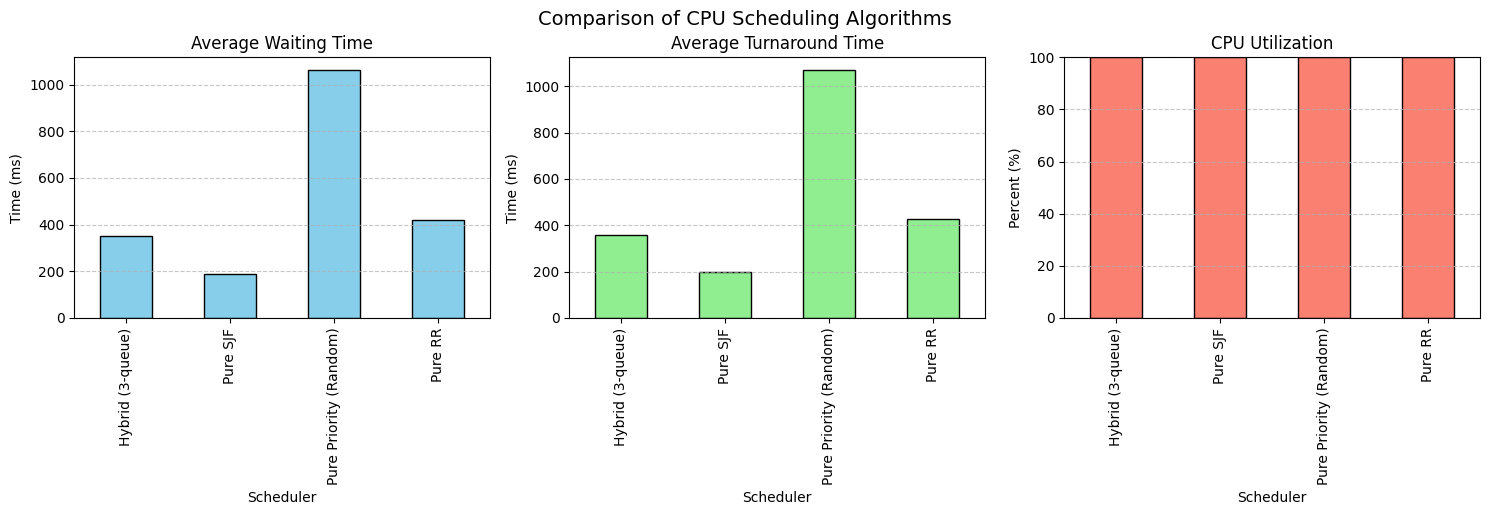

In [173]:
# ============================================================
# PLOT BAR CHARTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Avg Waiting Time
metrics_df['Avg Waiting Time'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Average Waiting Time')
axes[0].set_ylabel('Time (ms)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Avg Turnaround Time
metrics_df['Avg Turnaround Time'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Average Turnaround Time')
axes[1].set_ylabel('Time (ms)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# CPU Utilization
metrics_df['CPU Utilization (%)'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('CPU Utilization')
axes[2].set_ylabel('Percent (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Comparison of CPU Scheduling Algorithms', fontsize=14, y=1.02)
plt.show()

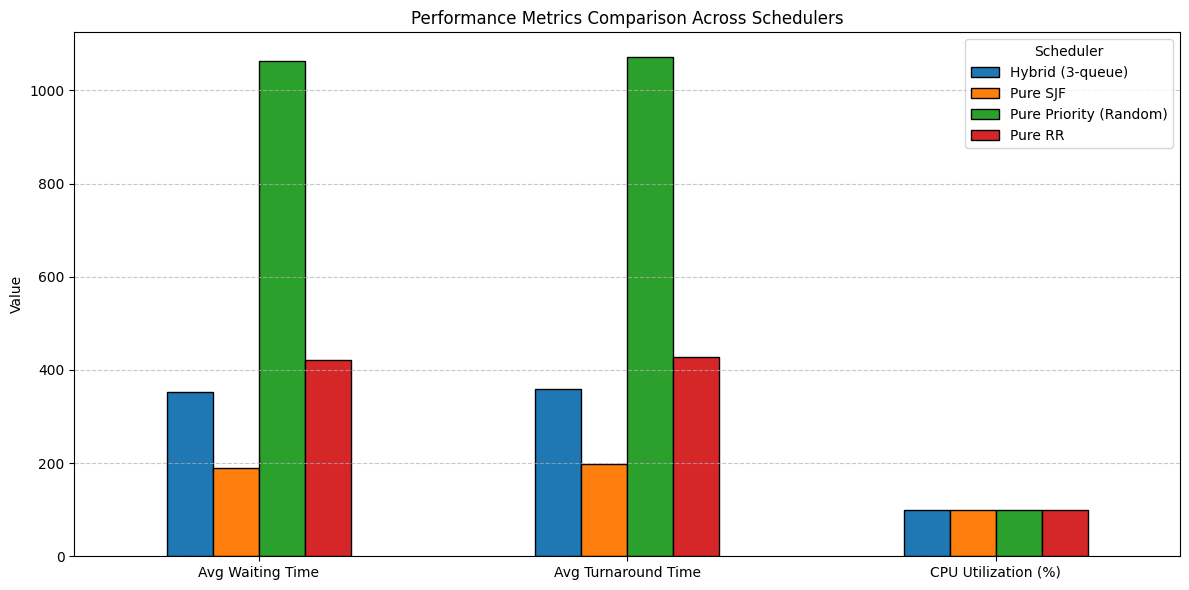


Priority distribution in Pure Priority (Random):
Priority
1     34
2     24
3     33
4     30
5     24
6     25
7     33
8     33
9     30
10    22
Name: count, dtype: int64


In [174]:
# ============================================================
# GROUPED BAR CHART (alternative view)
# ============================================================
metrics_df.T.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Performance Metrics Comparison Across Schedulers')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Scheduler')
plt.tight_layout()
plt.show()

# Optional: print priority distribution for reference
print("\nPriority distribution in Pure Priority (Random):")
print(priority_df['Priority'].value_counts().sort_index())

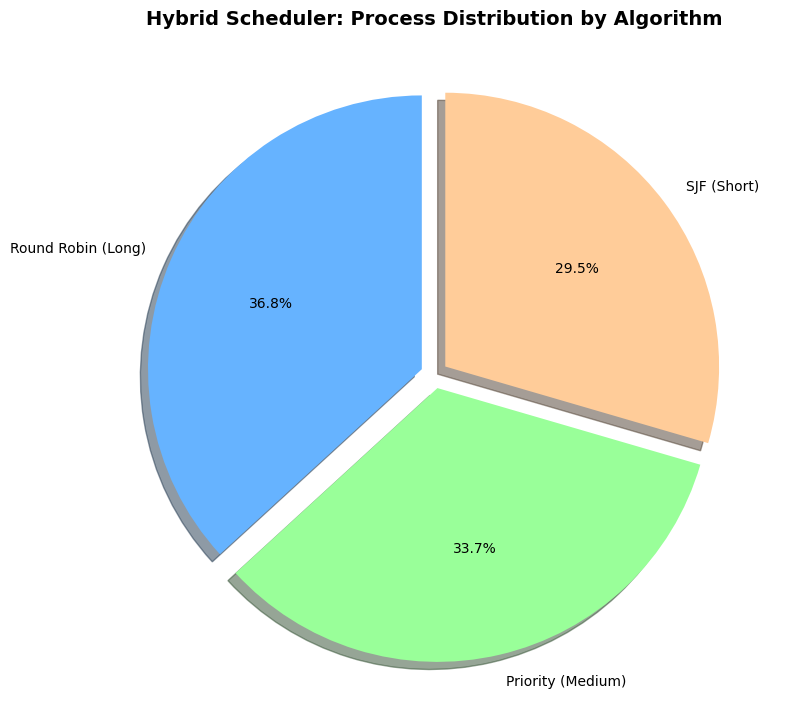

In [175]:
# ============================================================
# ADDITIONAL PROFESSIONAL CHARTS
# ============================================================

# 1. PIE CHART: Hybrid Scheduler Queue Distribution
# Count how many processes went to each algorithm in hybrid scheduler
hybrid_algo_counts = hybrid_df['Algorithm'].value_counts()
# Rename for clarity: Hybrid-SJF -> SJF (short), Hybrid-Priority -> Priority (medium), Hybrid-RR -> RR (long)
algo_labels = {'Hybrid-SJF': 'SJF (Short)', 'Hybrid-Priority': 'Priority (Medium)', 'Hybrid-RR': 'Round Robin (Long)'}
hybrid_algo_counts = hybrid_algo_counts.rename(index=algo_labels)

plt.figure(figsize=(8, 8))
colors_pie = ['#66b3ff', '#99ff99', '#ffcc99']
plt.pie(hybrid_algo_counts, labels=hybrid_algo_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors_pie, explode=(0.05, 0.05, 0.05), shadow=True)
plt.title('Hybrid Scheduler: Process Distribution by Algorithm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




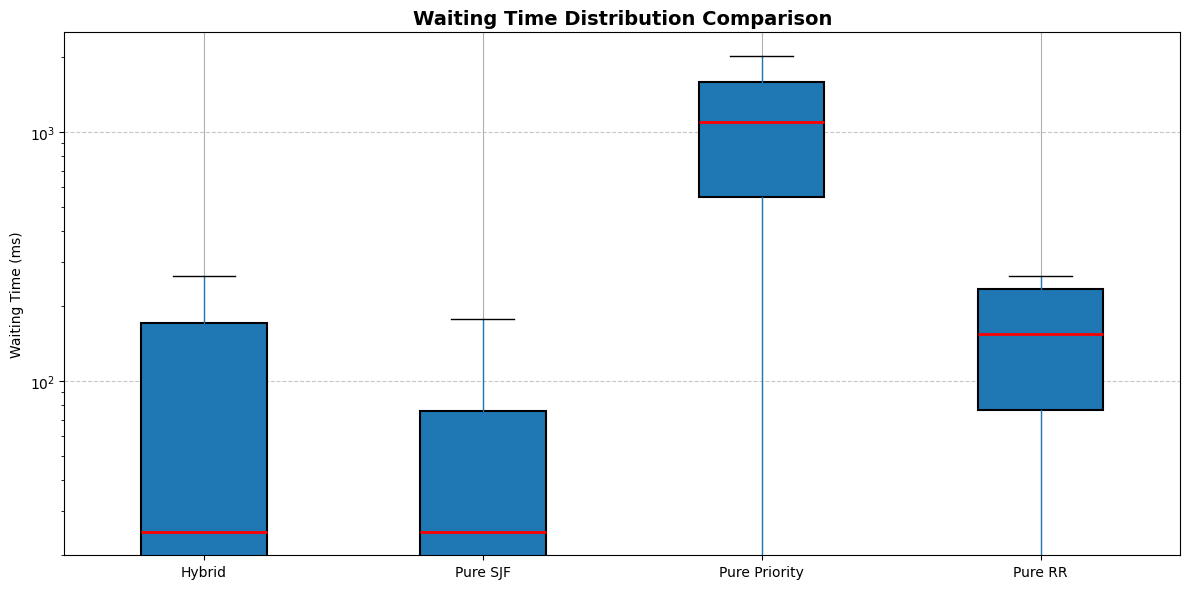

In [176]:
# 2. BOXPLOT: Waiting Time Distribution Across All Schedulers
# Combine waiting times from all schedulers into one DataFrame for boxplot
waiting_data = {
    'Hybrid': hybrid_df['WaitingTime'],
    'Pure SJF': sjf_df['WaitingTime'],
    'Pure Priority': priority_df['WaitingTime'],
    'Pure RR': rr_df['WaitingTime']
}
waiting_df = pd.DataFrame(waiting_data)

plt.figure(figsize=(12, 6))
bp = waiting_df.boxplot(column=['Hybrid', 'Pure SJF', 'Pure Priority', 'Pure RR'],
                        grid=True, patch_artist=True, showfliers=False,
                        boxprops=dict(linewidth=1.5),
                        medianprops=dict(linewidth=2, color='red'))
plt.title('Waiting Time Distribution Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Waiting Time (ms)')
plt.yscale('log')  # log scale because waiting times vary widely
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()